In [1]:
# --- imports
import pandas as pd
%load_ext autoreload
import segmentation_models_pytorch as smp
%autoreload 2
import numpy as np
import torch 
import copy

/home/tjdu/micromamba/envs/solar-forecasting-hk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.utils import (
    print_post_norm_stats,
    print_raw_night_stats,
    train_val_test_split_indices
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train_val_bc import(
    train_one_epoch,
    evaluate,
    evaluate_on_test,
    evaluate_csi_and_ghi,
)
from src.plot import(
    plot_full_images_from_loader,
)

from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)

In [3]:
bands_npz_name = "Data/bands/modeldata/bands_day_paired_30mins_new_fuzzy_no_twillight.npz"
elevation_npz_name = "Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [4]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
)

print("Saved:", out)
print("Final shape:", shape)

Saved: Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz
Final shape: (67638, 12, 50, 50)


In [5]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/new_combined_10mins_with_elev_landmask_fuzzy.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (67638, 12, 50, 50)
y shape: (67638, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


In [11]:
import numpy as np

def compute_means(arr):
    # arr: (T,H,W) or (T,1,H,W)
    if arr.ndim == 4:
        arr = arr[:, 0]
    return arr.mean(axis=(1,2))

def make_labels(c0, c1, csi,
                tw_cs_thr=76.0,      # W/m^2 : twilight if clear-sky GHI below this
                clear_thr=0.80,      # CSI mean threshold for "clear"
                cloudy_thr=0.35):    # CSI mean threshold for "cloudy"
    """
    Returns labels:
      0=twilight, 1=clear, 2=cloudy, 3=mixed
    """
    c0m  = compute_means(c0)
    c1m  = compute_means(c1)
    csim = compute_means(csi)

    labels = np.full(len(c1m), 3, dtype=np.int64)  # default mixed

    tw = c1m < tw_cs_thr
    labels[tw] = 0

    daytime = ~tw
    labels[daytime & (csim >= clear_thr)] = 1
    labels[daytime & (csim <= cloudy_thr)] = 2

    return labels, {"c0_mean": c0m, "c1_mean": c1m, "csi_mean": csim}


In [12]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

def stratified_split_grouped_by_time(labels, cams_time_min, train=0.8, val=0.1, test=0.1, seed=42):
    assert abs(train + val + test - 1.0) < 1e-9

    labels = np.asarray(labels)
    groups = np.asarray(cams_time_min)  # group key: same CAMS time => same y
    idx = np.arange(len(labels))

    # train vs tmp (val+test) using 5 folds (~20% holdout)
    sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    best = None
    target_tmp = val + test
    for tr, tmp in sgkf1.split(idx, labels, groups=groups):
        frac = len(tmp) / len(idx)
        score = abs(frac - target_tmp)
        if best is None or score < best[0]:
            best = (score, tr, tmp)
    _, tr_idx, tmp_idx = best

    # tmp -> val/test using 2 folds (~50/50, perfect for 0.1/0.1)
    sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=seed + 1)
    v_rel, te_rel = next(sgkf2.split(tmp_idx, labels[tmp_idx], groups=groups[tmp_idx]))

    idx_train = tr_idx
    idx_val   = tmp_idx[v_rel]
    idx_test  = tmp_idx[te_rel]

    # hard guarantee: no time overlap
    assert set(groups[idx_train]).isdisjoint(set(groups[idx_test]))
    assert set(groups[idx_train]).isdisjoint(set(groups[idx_val]))
    assert set(groups[idx_val]).isdisjoint(set(groups[idx_test]))

    return idx_train, idx_val, idx_test


In [15]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]
print("paired samples:", len(t))
print("unique CAMS times:", len(np.unique(t)))
print("duplicates exist:", len(t) != len(np.unique(t)))


paired samples: 67638
unique CAMS times: 46277
duplicates exist: True


In [18]:
c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)

In [20]:
cams_time_min = t.astype(np.int64, copy=False)
labels = labels.astype(np.int64, copy=False)

In [26]:
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, cams_time_min, 0.8, 0.1, 0.1, seed=42)


In [27]:
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

In [29]:
#print shape
print("Train set:", X_train.shape, y_train.shape)
print("Val set:  ", X_val.shape,   y_val.shape)
print("Test set: ", X_test.shape,  y_test.shape)

Train set: (54101, 12, 50, 50) (54101, 1, 50, 50)
Val set:   (6783, 12, 50, 50) (6783, 1, 50, 50)
Test set:  (6754, 12, 50, 50) (6754, 1, 50, 50)


channel_mean: [238.66437  247.30698  254.30418  276.60678  259.0976   278.6026
 277.43613  274.47504  263.09882   39.706436  34.05114    0.3652  ]
channel_std: [ 9.577975   11.47075    12.711327   19.808594   12.378416   20.610844
 20.99358    20.233007   16.079489    0.3124471  80.81088     0.48147944]

In [30]:
# 4) compute per-channel min max on TRAIN only
#    X_train: (T_train, C, H, W)
channel_min = np.nanmin(X_train, axis=(0, 2, 3))   # (C,)
channel_max = np.nanmax(X_train, axis=(0, 2, 3))   # (C,)

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

print("channel_min:", channel_min)
print("channel_max:", channel_max)

np.savez(
    "Data/static/minmax_strat_stats_day_30mins_no_twillight_fuzzy_new_split.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)


channel_min: [187.04999 183.7     185.03    182.54    208.81999 182.60999 181.82
 182.57999 185.31999  38.89      0.        0.     ]
channel_max: [258.57     268.59     272.9      307.63     279.22     311.44998
 310.09     302.99     281.3       40.579998 804.1716     1.      ]


In [31]:
from torch.utils.data import DataLoader

train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)

batch_size = 32


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


In [39]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

54101 6783 6754


In [33]:
import kornia
import torch.nn as nn
criterion_reg  = nn.SmoothL1Loss(beta=0.03)  # sharper than 0.05
criterion_ssim = kornia.losses.SSIMLoss(window_size=11, reduction="mean")

def grad_loss(pred, true):
    dx_p = pred[..., :, 1:] - pred[..., :, :-1]
    dy_p = pred[..., 1:, :] - pred[..., :-1, :]
    dx_t = true[..., :, 1:] - true[..., :, :-1]
    dy_t = true[..., 1:, :] - true[..., :-1, :]
    return (dx_p - dx_t).abs().mean() + (dy_p - dy_t).abs().mean()

def lap_loss(pred, true):
    k = pred.new_tensor([[0,1,0],[1,-4,1],[0,1,0]]).reshape(1,1,3,3)
    lp = torch.nn.functional.conv2d(pred, k, padding=1)
    lt = torch.nn.functional.conv2d(true, k, padding=1)
    return (lp - lt).abs().mean()

def combined_loss(y_pred, y_true, w_reg=0.7, w_ssim=0.1, w_grad=0.15, w_lap=0.05):
    return (
        w_reg * criterion_reg(y_pred, y_true)
        + w_ssim * criterion_ssim(y_pred, y_true)
        + w_grad * grad_loss(y_pred, y_true)
        + w_lap * lap_loss(y_pred, y_true)
    )


In [19]:
! export CUDA_VISIBLE_DEVICES=0 

In [34]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)

In [ ]:
from src.model_Twin import TwinFiLMUNetTiny,SpatialMoEUNet
model = TwinFiLMUNetTiny(feature_size=48).to(device)

In [36]:
# ...existing code...
import os, torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("torch.cuda.is_available:", torch.cuda.is_available())
print("visible GPU count:", torch.cuda.device_count())

# confirm model parameters device
print("model device:", next(model.parameters()).device)

# show per-GPU memory usage (should be nonzero on only one device)
for i in range(torch.cuda.device_count()):
    used = torch.cuda.memory_allocated(i) / 1024**2
    reserved = torch.cuda.memory_reserved(i) / 1024**2
    print(f"GPU {i}: allocated={used:.1f}MB reserved={reserved:.1f}MB")

# enforce single visible GPU
assert torch.cuda.device_count() == 1, f"Expected 1 visible GPU, got {torch.cuda.device_count()}"
# ...existing code...

CUDA_VISIBLE_DEVICES: None
torch.cuda.is_available: True
visible GPU count: 2
model device: cuda:0
GPU 0: allocated=1.5MB reserved=2.0MB
GPU 1: allocated=0.0MB reserved=0.0MB


AssertionError: Expected 1 visible GPU, got 2

In [41]:
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

model = TwinFiLMUNetTiny(feature_size=48).to(device)

# -----------------------------
# Optimizer + scheduler
# -----------------------------
total_epochs = 150
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

scheduler = OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_loader),
    epochs=total_epochs,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=5.0,        # initial lr = max_lr/div_factor
    final_div_factor=50.0  # final lr = initial_lr/final_div_factor
)

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(total_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, combined_loss, device, scheduler)
    val_loss, val_rmse = evaluate(model, val_loader, combined_loss, device)

    print(
        f"Epoch {epoch+1:03d}/{total_epochs}: "
        f"loss={train_loss:.6f} | val_loss {val_loss:.4f} | val_rmse {val_rmse:.4f} | "
        f"lr {optimizer.param_groups[0]['lr']}"
    )

Epoch 001/150: loss=0.118213 | val_loss 0.1035 | val_rmse 0.1646 | lr 0.00010437082321996735
Epoch 002/150: loss=0.097567 | val_loss 0.0899 | val_rmse 0.1366 | lr 0.00011729225192366749
Epoch 003/150: loss=0.090833 | val_loss 0.0962 | val_rmse 0.1452 | lr 0.00013819951330496742
Epoch 004/150: loss=0.088295 | val_loss 0.0881 | val_rmse 0.1396 | lr 0.00016617878792875404
Epoch 005/150: loss=0.085179 | val_loss 0.0841 | val_rmse 0.1266 | lr 0.00020000715116299248
Epoch 006/150: loss=0.083786 | val_loss 0.0838 | val_rmse 0.1262 | lr 0.00023820602505250578
Epoch 007/150: loss=0.082058 | val_loss 0.0851 | val_rmse 0.1275 | lr 0.00027910580434756493
Epoch 008/150: loss=0.081059 | val_loss 0.0823 | val_rmse 0.1279 | lr 0.00032091883199782616
Epoch 009/150: loss=0.079659 | val_loss 0.0805 | val_rmse 0.1197 | lr 0.00036181753448178046
Epoch 010/150: loss=0.078400 | val_loss 0.0780 | val_rmse 0.1209 | lr 0.00040001430181459363
Epoch 011/150: loss=0.077993 | val_loss 0.0772 | val_rmse 0.1182 | lr 

KeyboardInterrupt: 

In [42]:
b = next(iter(train_loader))
print(type(b))
if isinstance(b, (list, tuple)):
    print("len:", len(b), "types:", [type(x) for x in b])
elif isinstance(b, dict):
    print("keys:", b.keys())

<class 'list'>
len: 2 types: [<class 'torch.Tensor'>, <class 'torch.Tensor'>]


In [57]:
# usage
metrics = evaluate_on_test(model, test_loader, device)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

RMSE: 0.103346
rRMSE: 0.147948
R2: 0.891392
MBE: -0.007568
MAE: 0.064737
mean_true: 0.698530


In [ ]:
no twillight included sigmoid 
RMSE: 0.130254
rRMSE: 0.183818
R2: 0.819233
MBE: -0.001009
MAE: 0.083949
mean_true: 0.708604

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

twillight included sigmoid 
RMSE: 0.169765
rRMSE: 0.236192
R2: 0.703104
MBE: 0.018563
MAE: 0.101059
mean_true: 0.718756

swin
{'CSI_RMSE': 0.1379673331975937,
 'CSI_rRMSE': 0.19519218802452087,
 'CSI_R2': 0.7941124439239502,
 'CSI_MBE': 0.01562388613820076,
 'CSI_MAE': 0.08873958885669708,
 'CSI_mean_true': 0.7068281769752502,
 'GHI_RMSE': 78.64848327636719,
 'GHI_rRMSE': 0.1939978450536728,
 'GHI_R2': 0.9189393520355225,
 'GHI_MBE': 13.343442916870117,
 'GHI_MAE': 46.85791015625,
 'GHI_mean_true': 405.4090576171875}

CSI_RMSE: 0.103346
CSI_rRMSE: 0.147948
CSI_R2: 0.891392
CSI_MBE: -0.007568
CSI_MAE: 0.064737
CSI_mean_true: 0.698530
GHI_RMSE: 14.872605
GHI_rRMSE: 0.144840
GHI_R2: 0.952227
GHI_MBE: -0.748844
GHI_MAE: 8.821382
GHI_mean_true: 102.682755


CSI_RMSE: 0.133899
CSI_rRMSE: 0.189436
CSI_R2: 0.806077
CSI_MBE: 0.008085
CSI_MAE: 0.086178
CSI_mean_true: 0.706828
GHI_RMSE: 76.838295
GHI_rRMSE: 0.189533
GHI_R2: 0.922628
GHI_MBE: 8.518705
GHI_MAE: 45.806358
GHI_mean_true: 405.409058

In [ ]:
# ckpt_path = "Model_checkpoint/ckpt_last2.pt"

# torch.save({
#     "epoch": epoch,                      # current epoch index (0-based)
#     "model": model.state_dict(),
#     "optimizer": optimizer.state_dict(),
#     "scheduler": scheduler.state_dict() if scheduler is not None else None,
# }, ckpt_path)


In [49]:
PATH = "Model_checkpoint/Swin+_elevation_no_twil_10mins_fuzzy_new_pairs.pth"
torch.save(model.state_dict(), PATH)

In [ ]:
import torch
import torch.nn.functional as F
from src.model_Twin import(TwinFiLMUNetTiny3L,TwinFiLMUNetTiny) 
# 1) load checkpoint
model = TwinFiLMUNetTiny(feature_size = 48)
model.load_state_dict(torch.load(PATH))
model.to(device)

In [48]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_30mins_new_fuzzy_no_twillight.npz")
cams_data = cams["data"]             # shape (T, 2, H, W)
time_mins = cams["time_min"] 
ghi_cs_all = cams_data[:, 1, :, :]   # c1 = clear-sky GHI, shape (T, H, W)
ghi_cs_test = ghi_cs_all[idx_test]   # shape (N_test, H, W)
# if you want explicit channel dim:
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (N_test, 1, H, W)

from src.evaluate import rmse_by_time_bucket
rep = rmse_by_time_bucket(model, test_loader, device, time_mins, idx_test)
for k,v in rep.items():
    print(k, v)


night(00-05) None
morning(05-08) {'N': 561, 'RMSE': 0.14372203470957107, 'MAE': 0.09052965564240374, 'MBE': -0.020164449916955304}
day(08-16) {'N': 5116, 'RMSE': 0.09309546059330133, 'MAE': 0.059005407662910174, 'MBE': -0.00599920659227103}
evening(16-19) {'N': 1077, 'RMSE': 0.12267436435309843, 'MAE': 0.07853085828116207, 'MBE': -0.00846152873138725}
twilight/late(19-24) None


In [56]:
metrics = evaluate_csi_and_ghi(model, test_loader, device, ghi_cs_test)
for k, v in metrics.items():
    print(f"{k}: {v:.6f}")


CSI_RMSE: 0.103346
CSI_rRMSE: 0.147948
CSI_R2: 0.891392
CSI_MBE: -0.007568
CSI_MAE: 0.064737
CSI_mean_true: 0.698530
GHI_RMSE: 14.872605
GHI_rRMSE: 0.144840
GHI_R2: 0.952227
GHI_MBE: -0.748844
GHI_MAE: 8.821382
GHI_mean_true: 102.682755


In [52]:
14.872605*4

59.49042

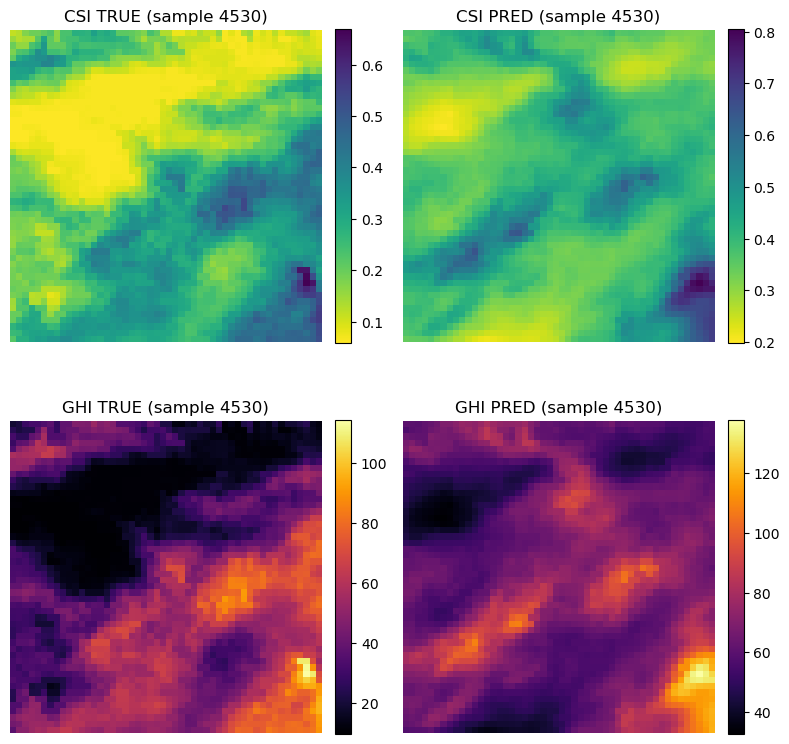

In [58]:
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=1,
    seed=5
)

NameError: name 'time_test' is not defined

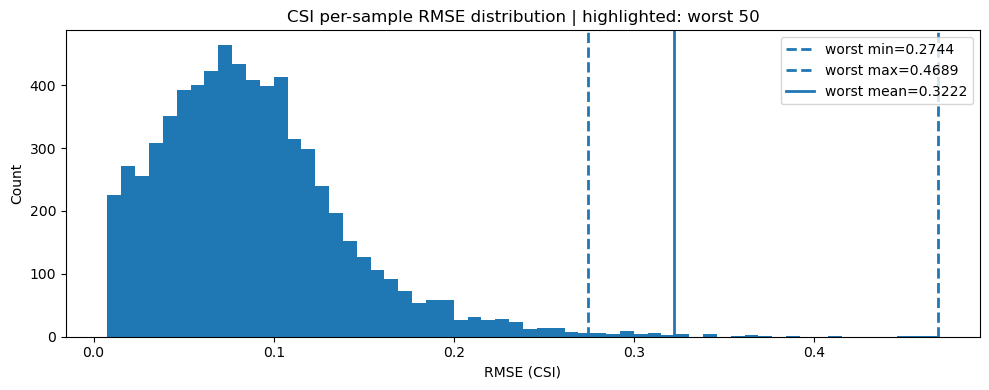

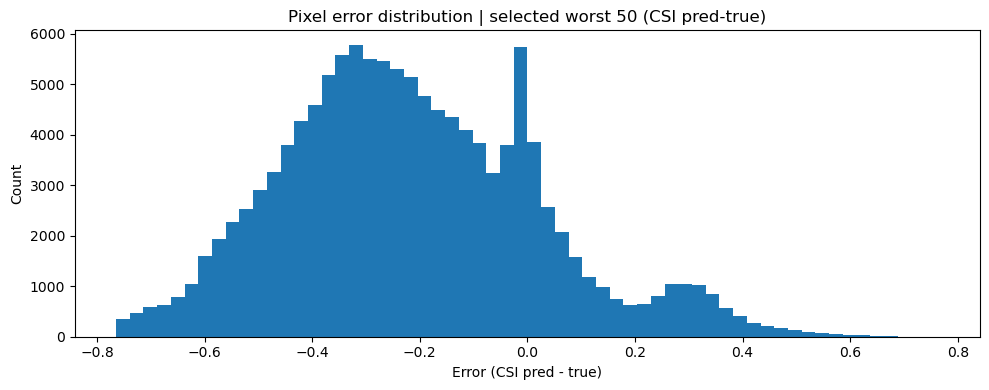

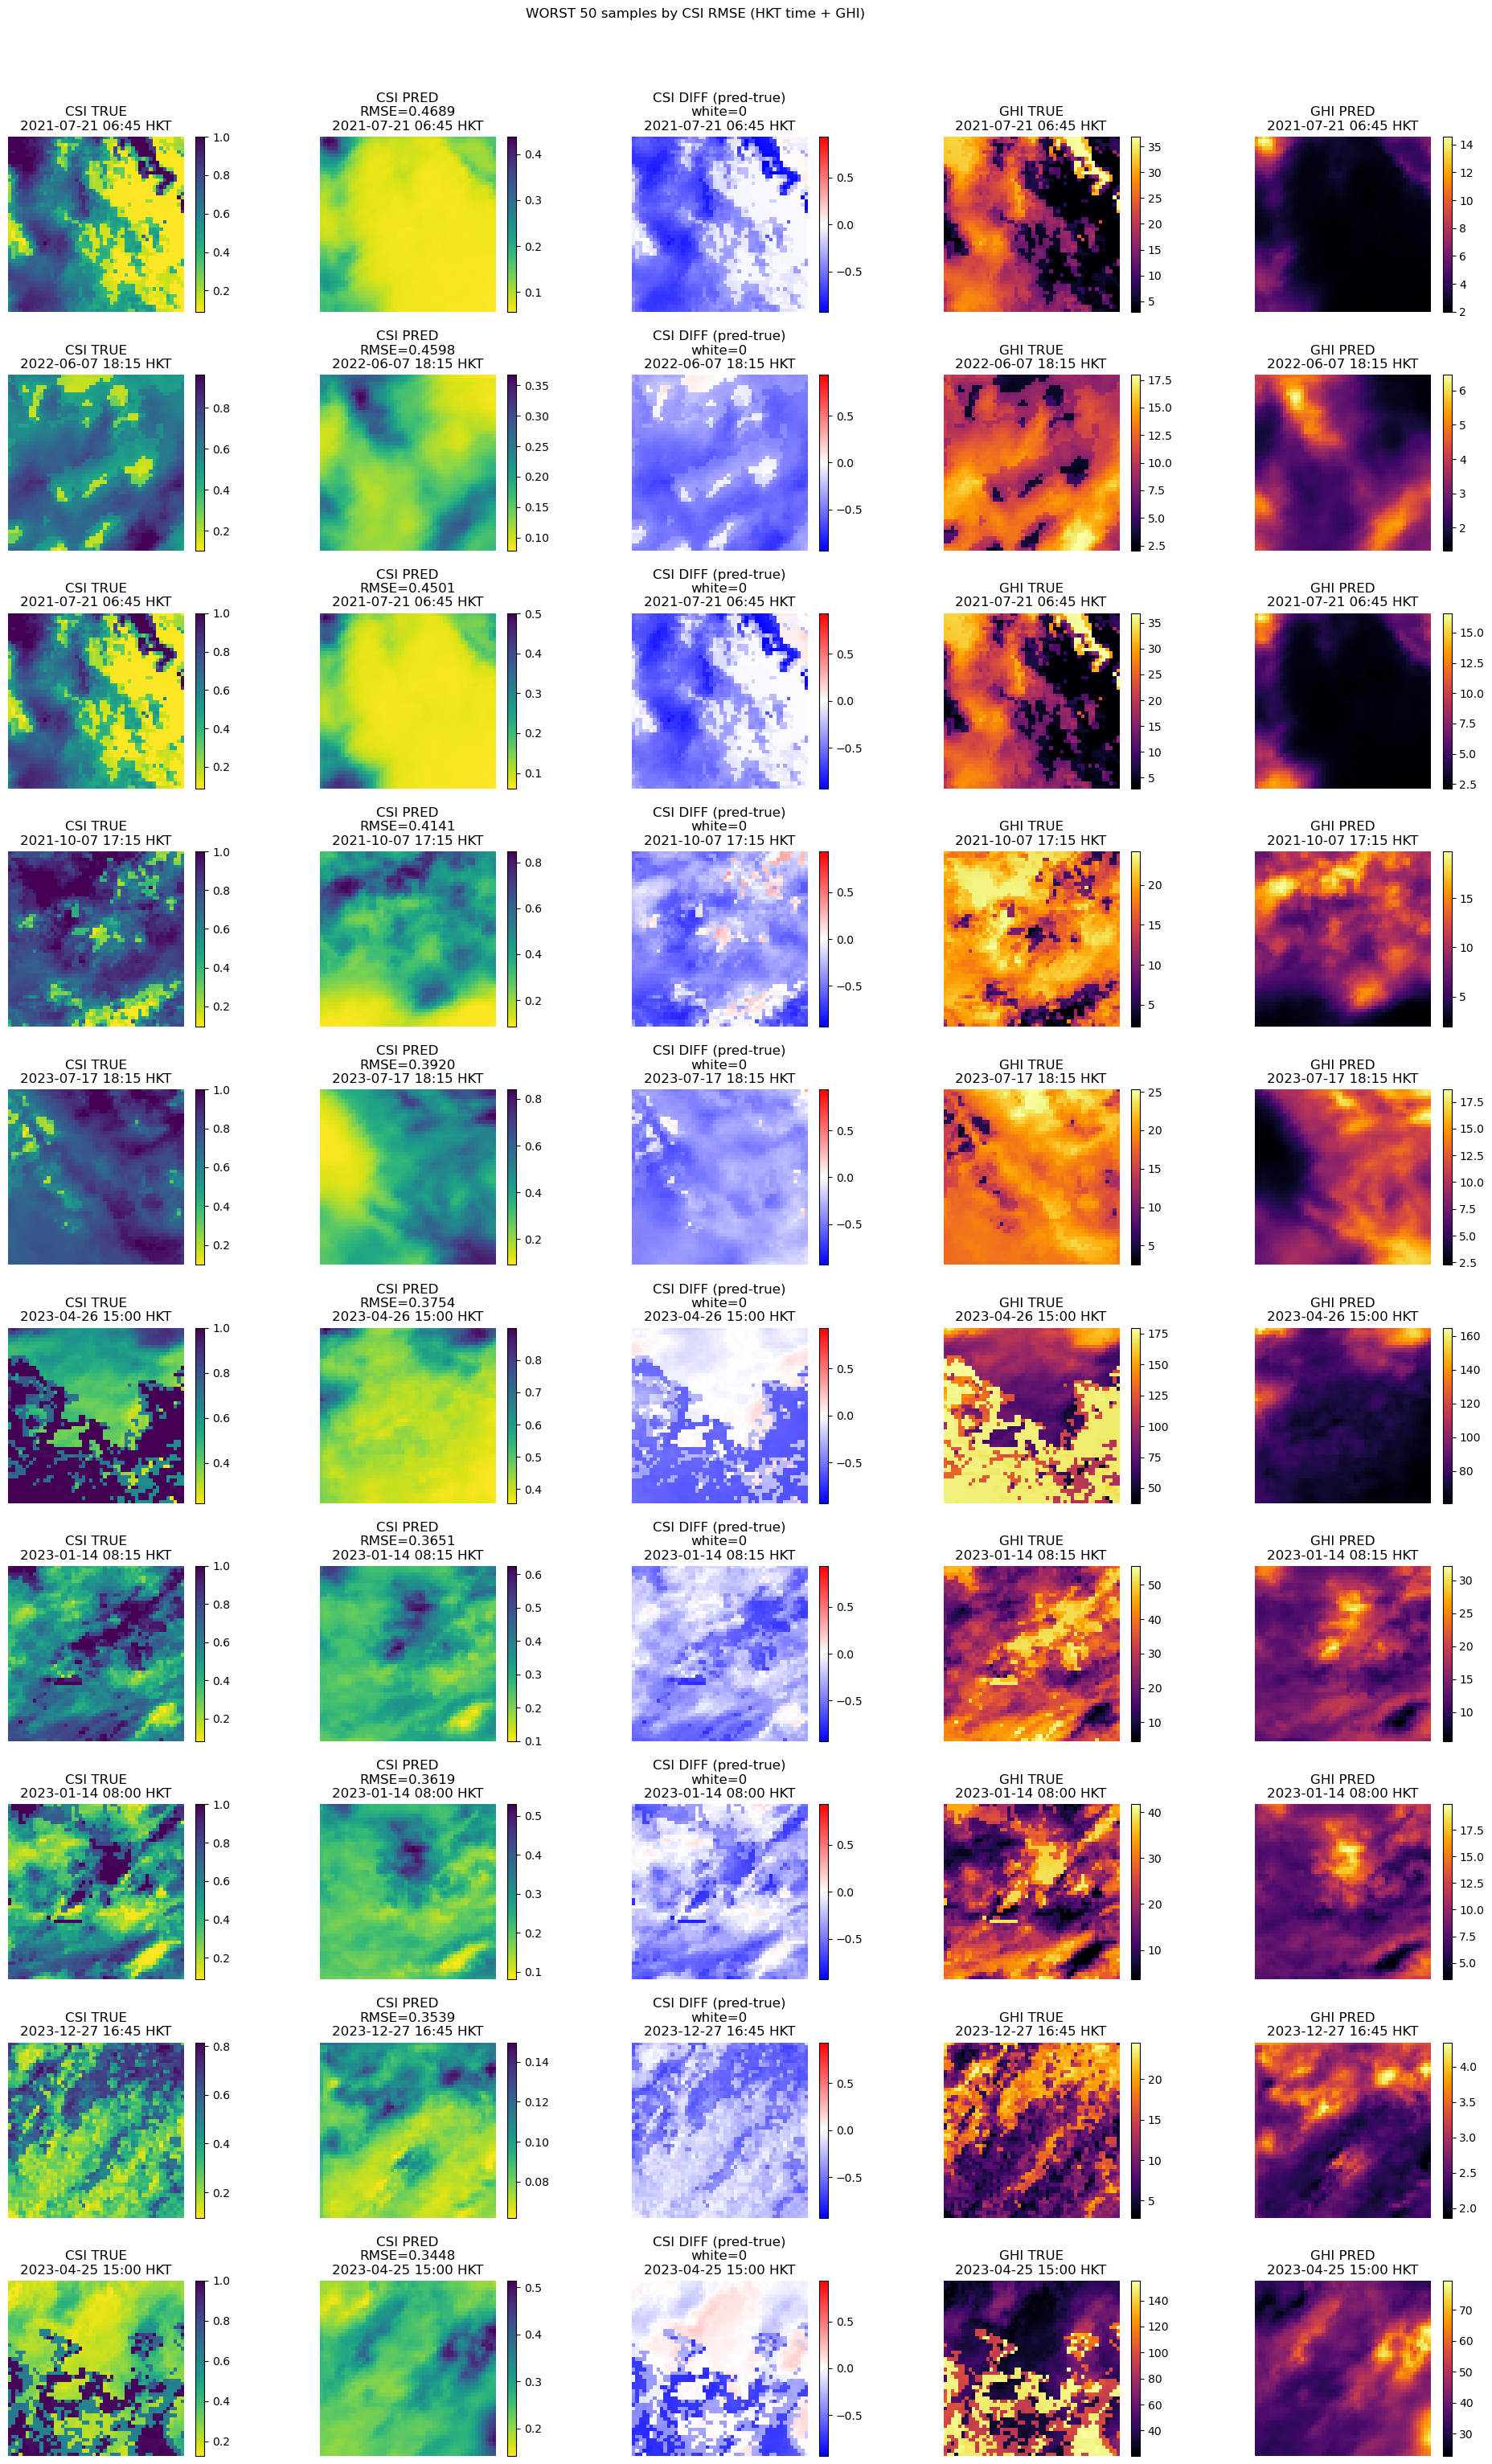

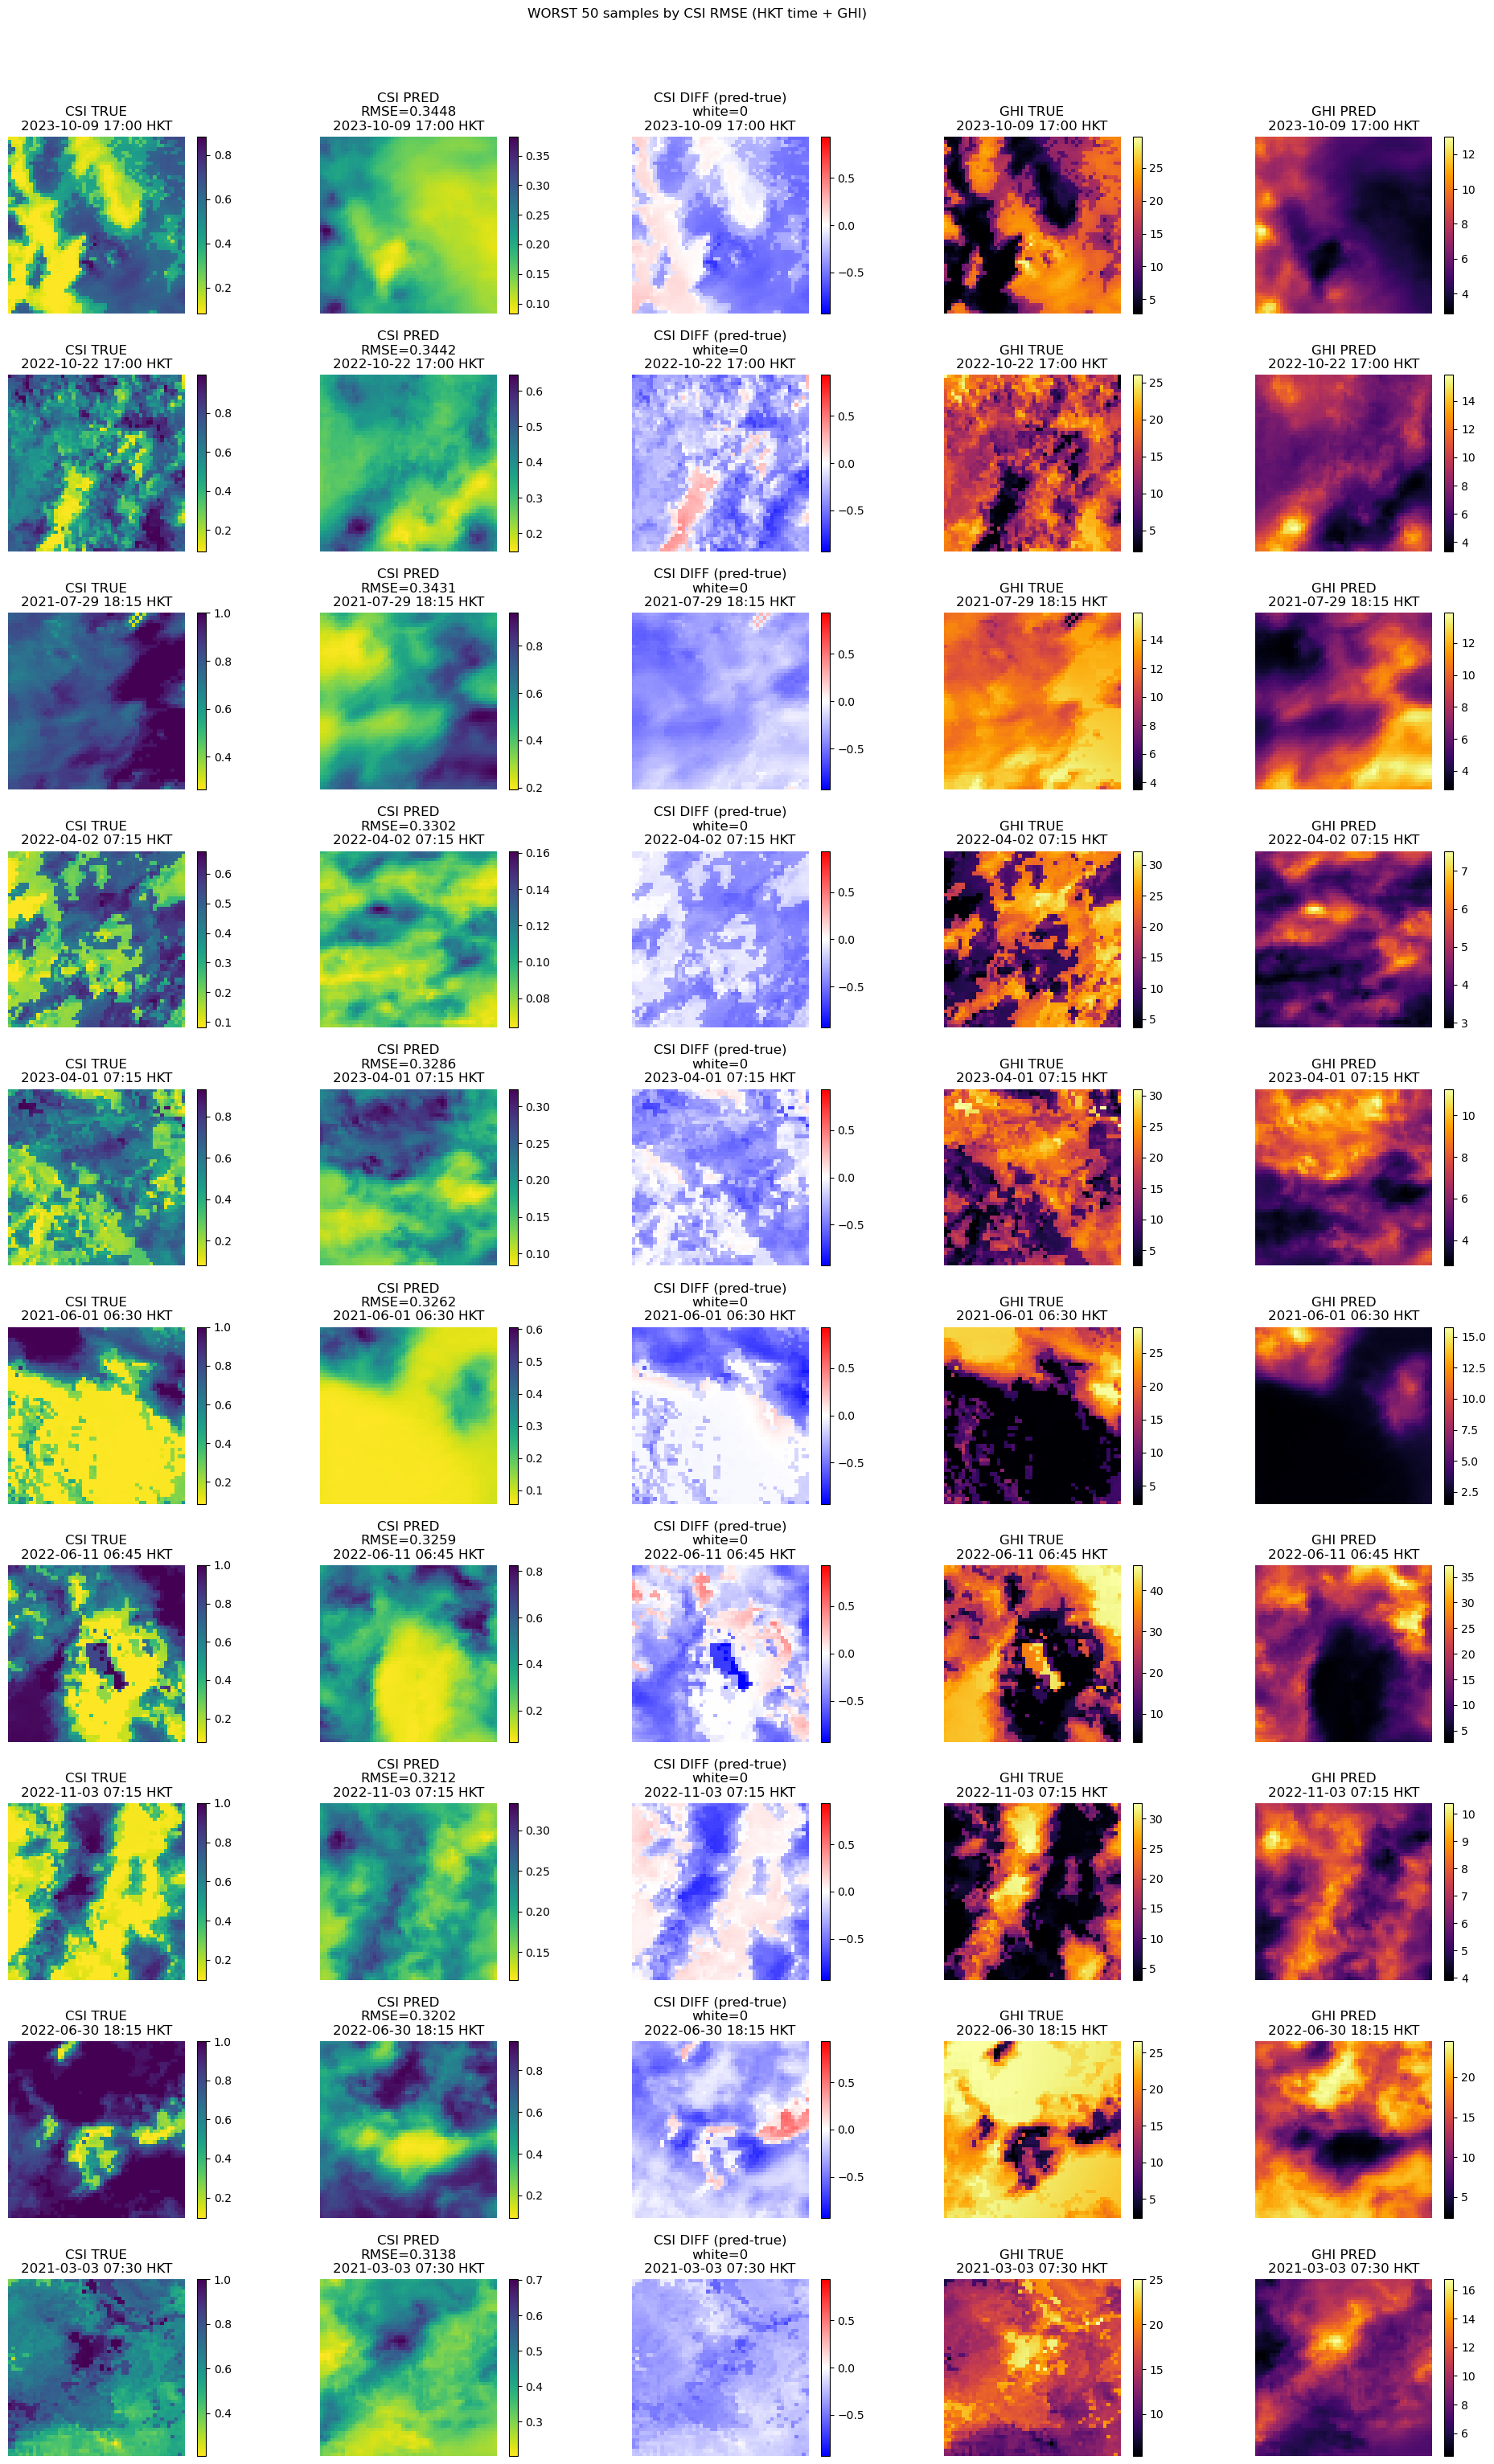

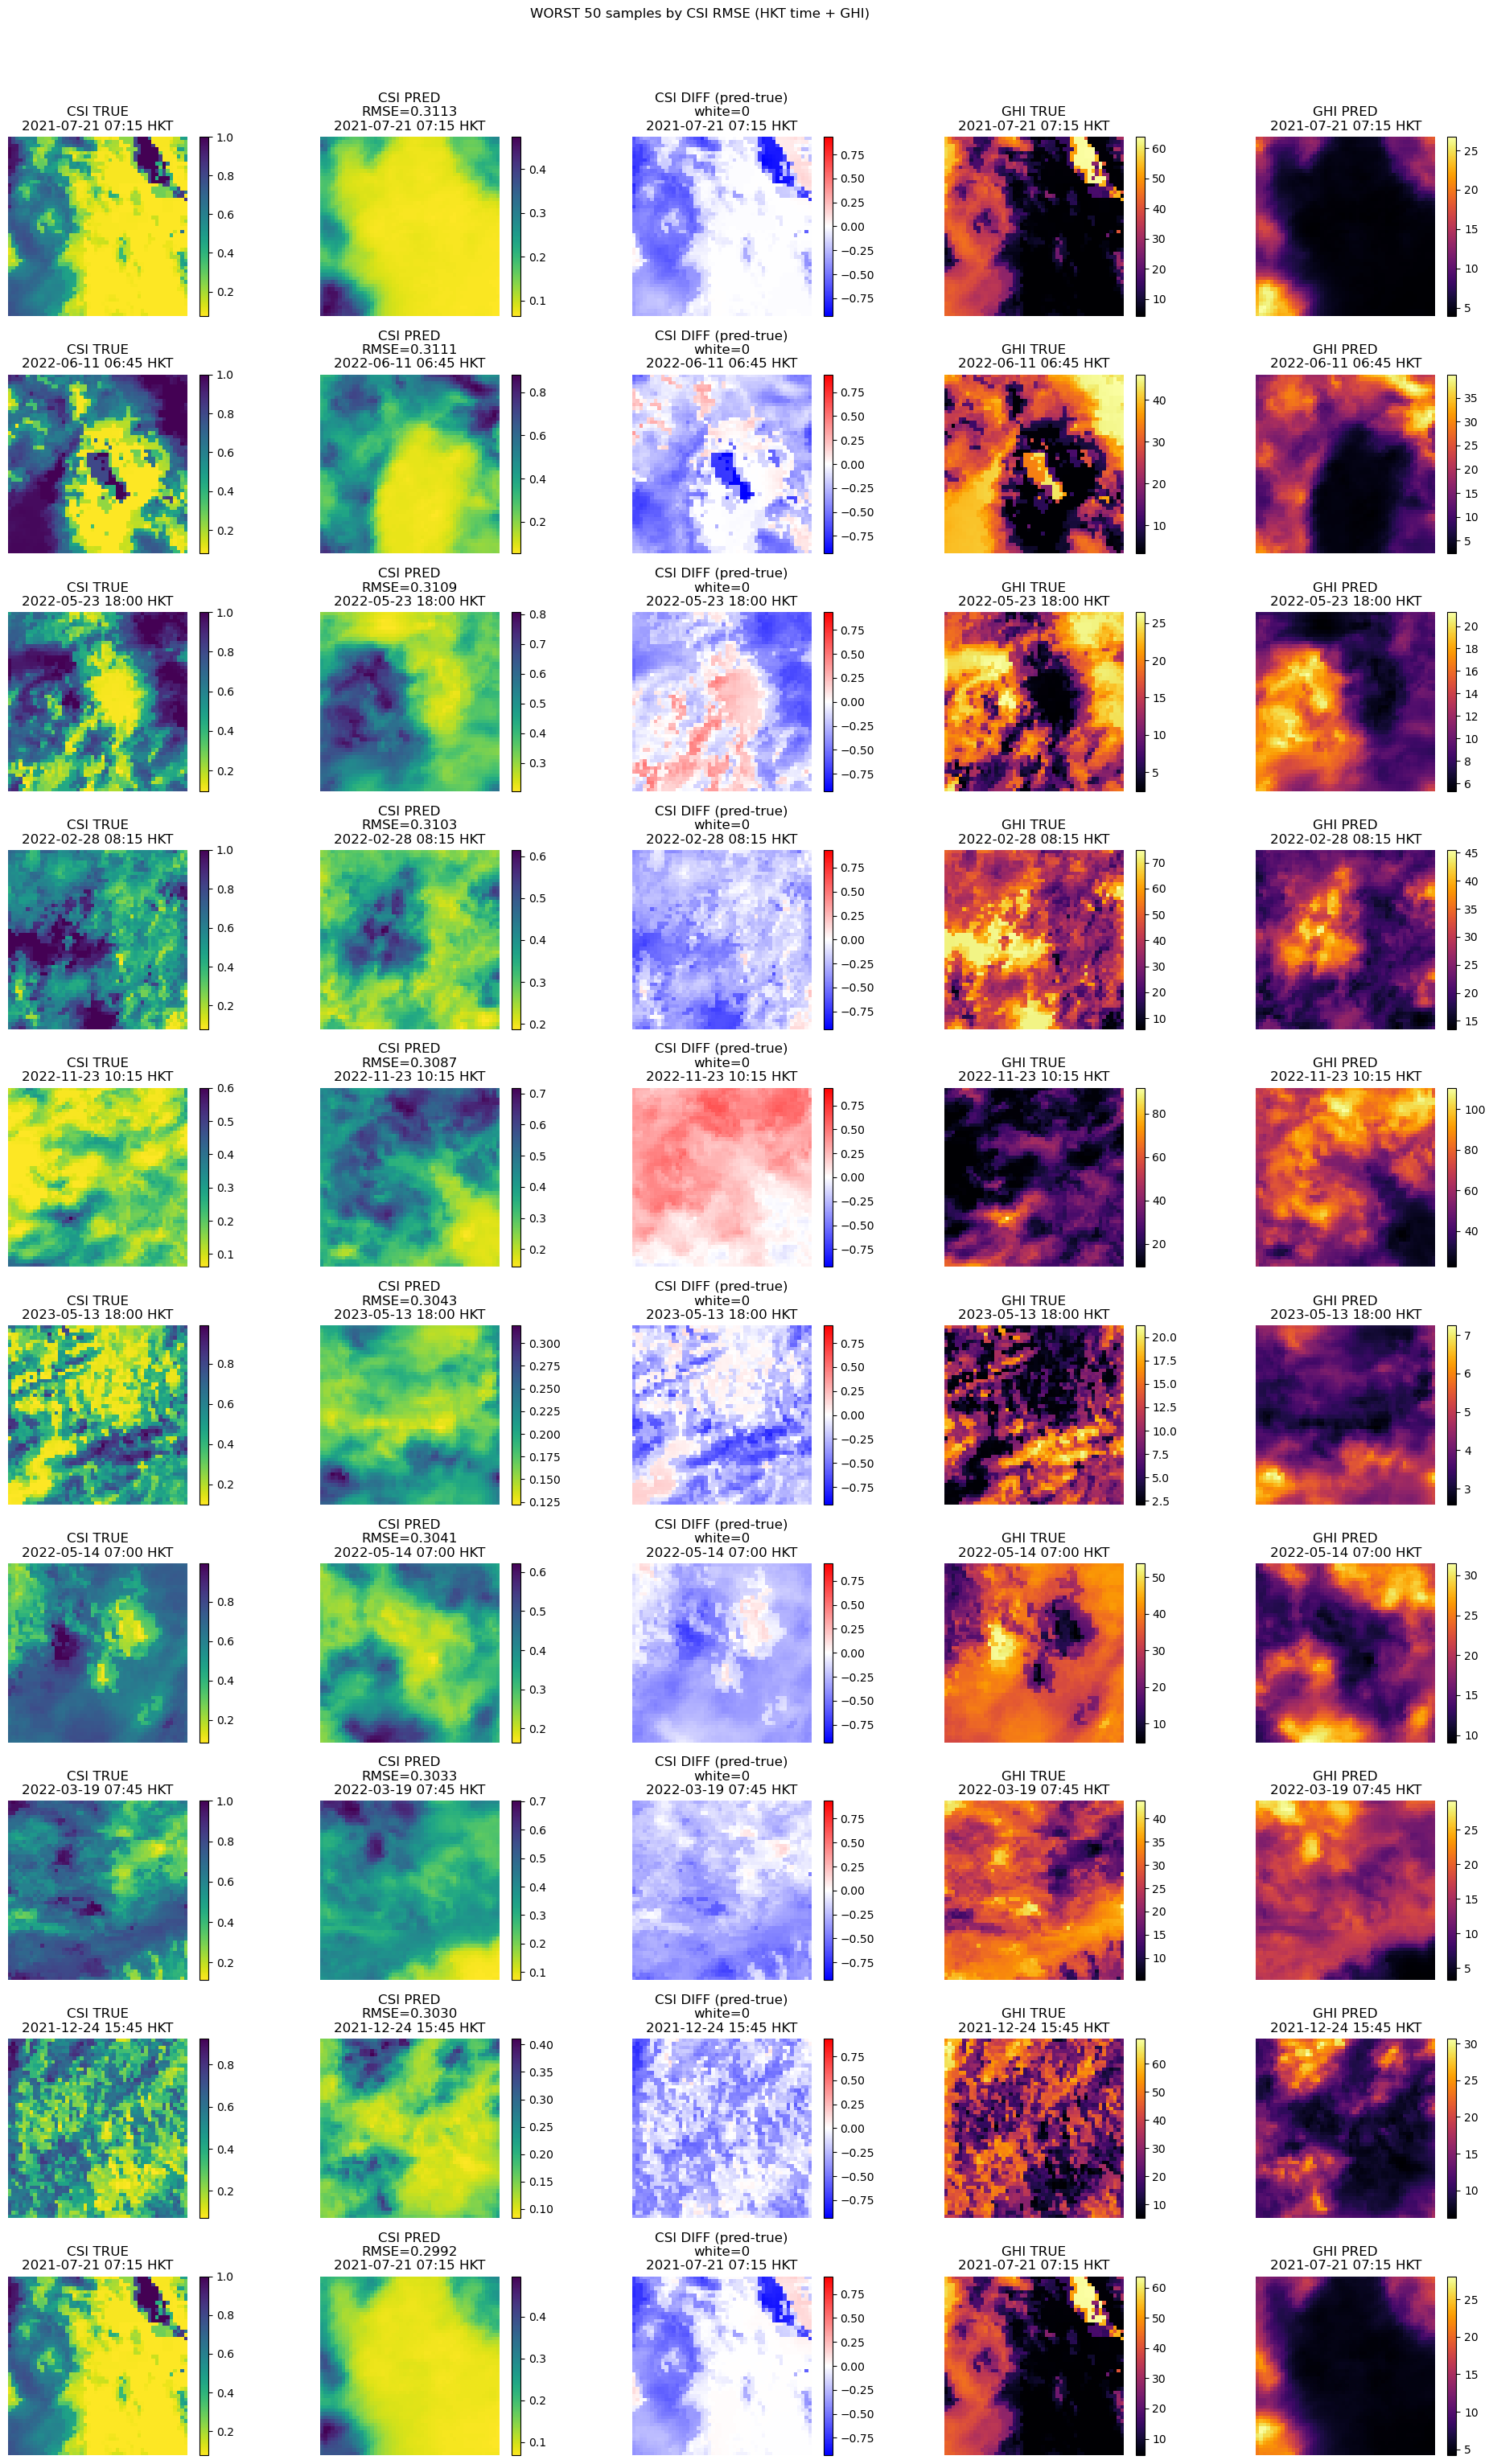

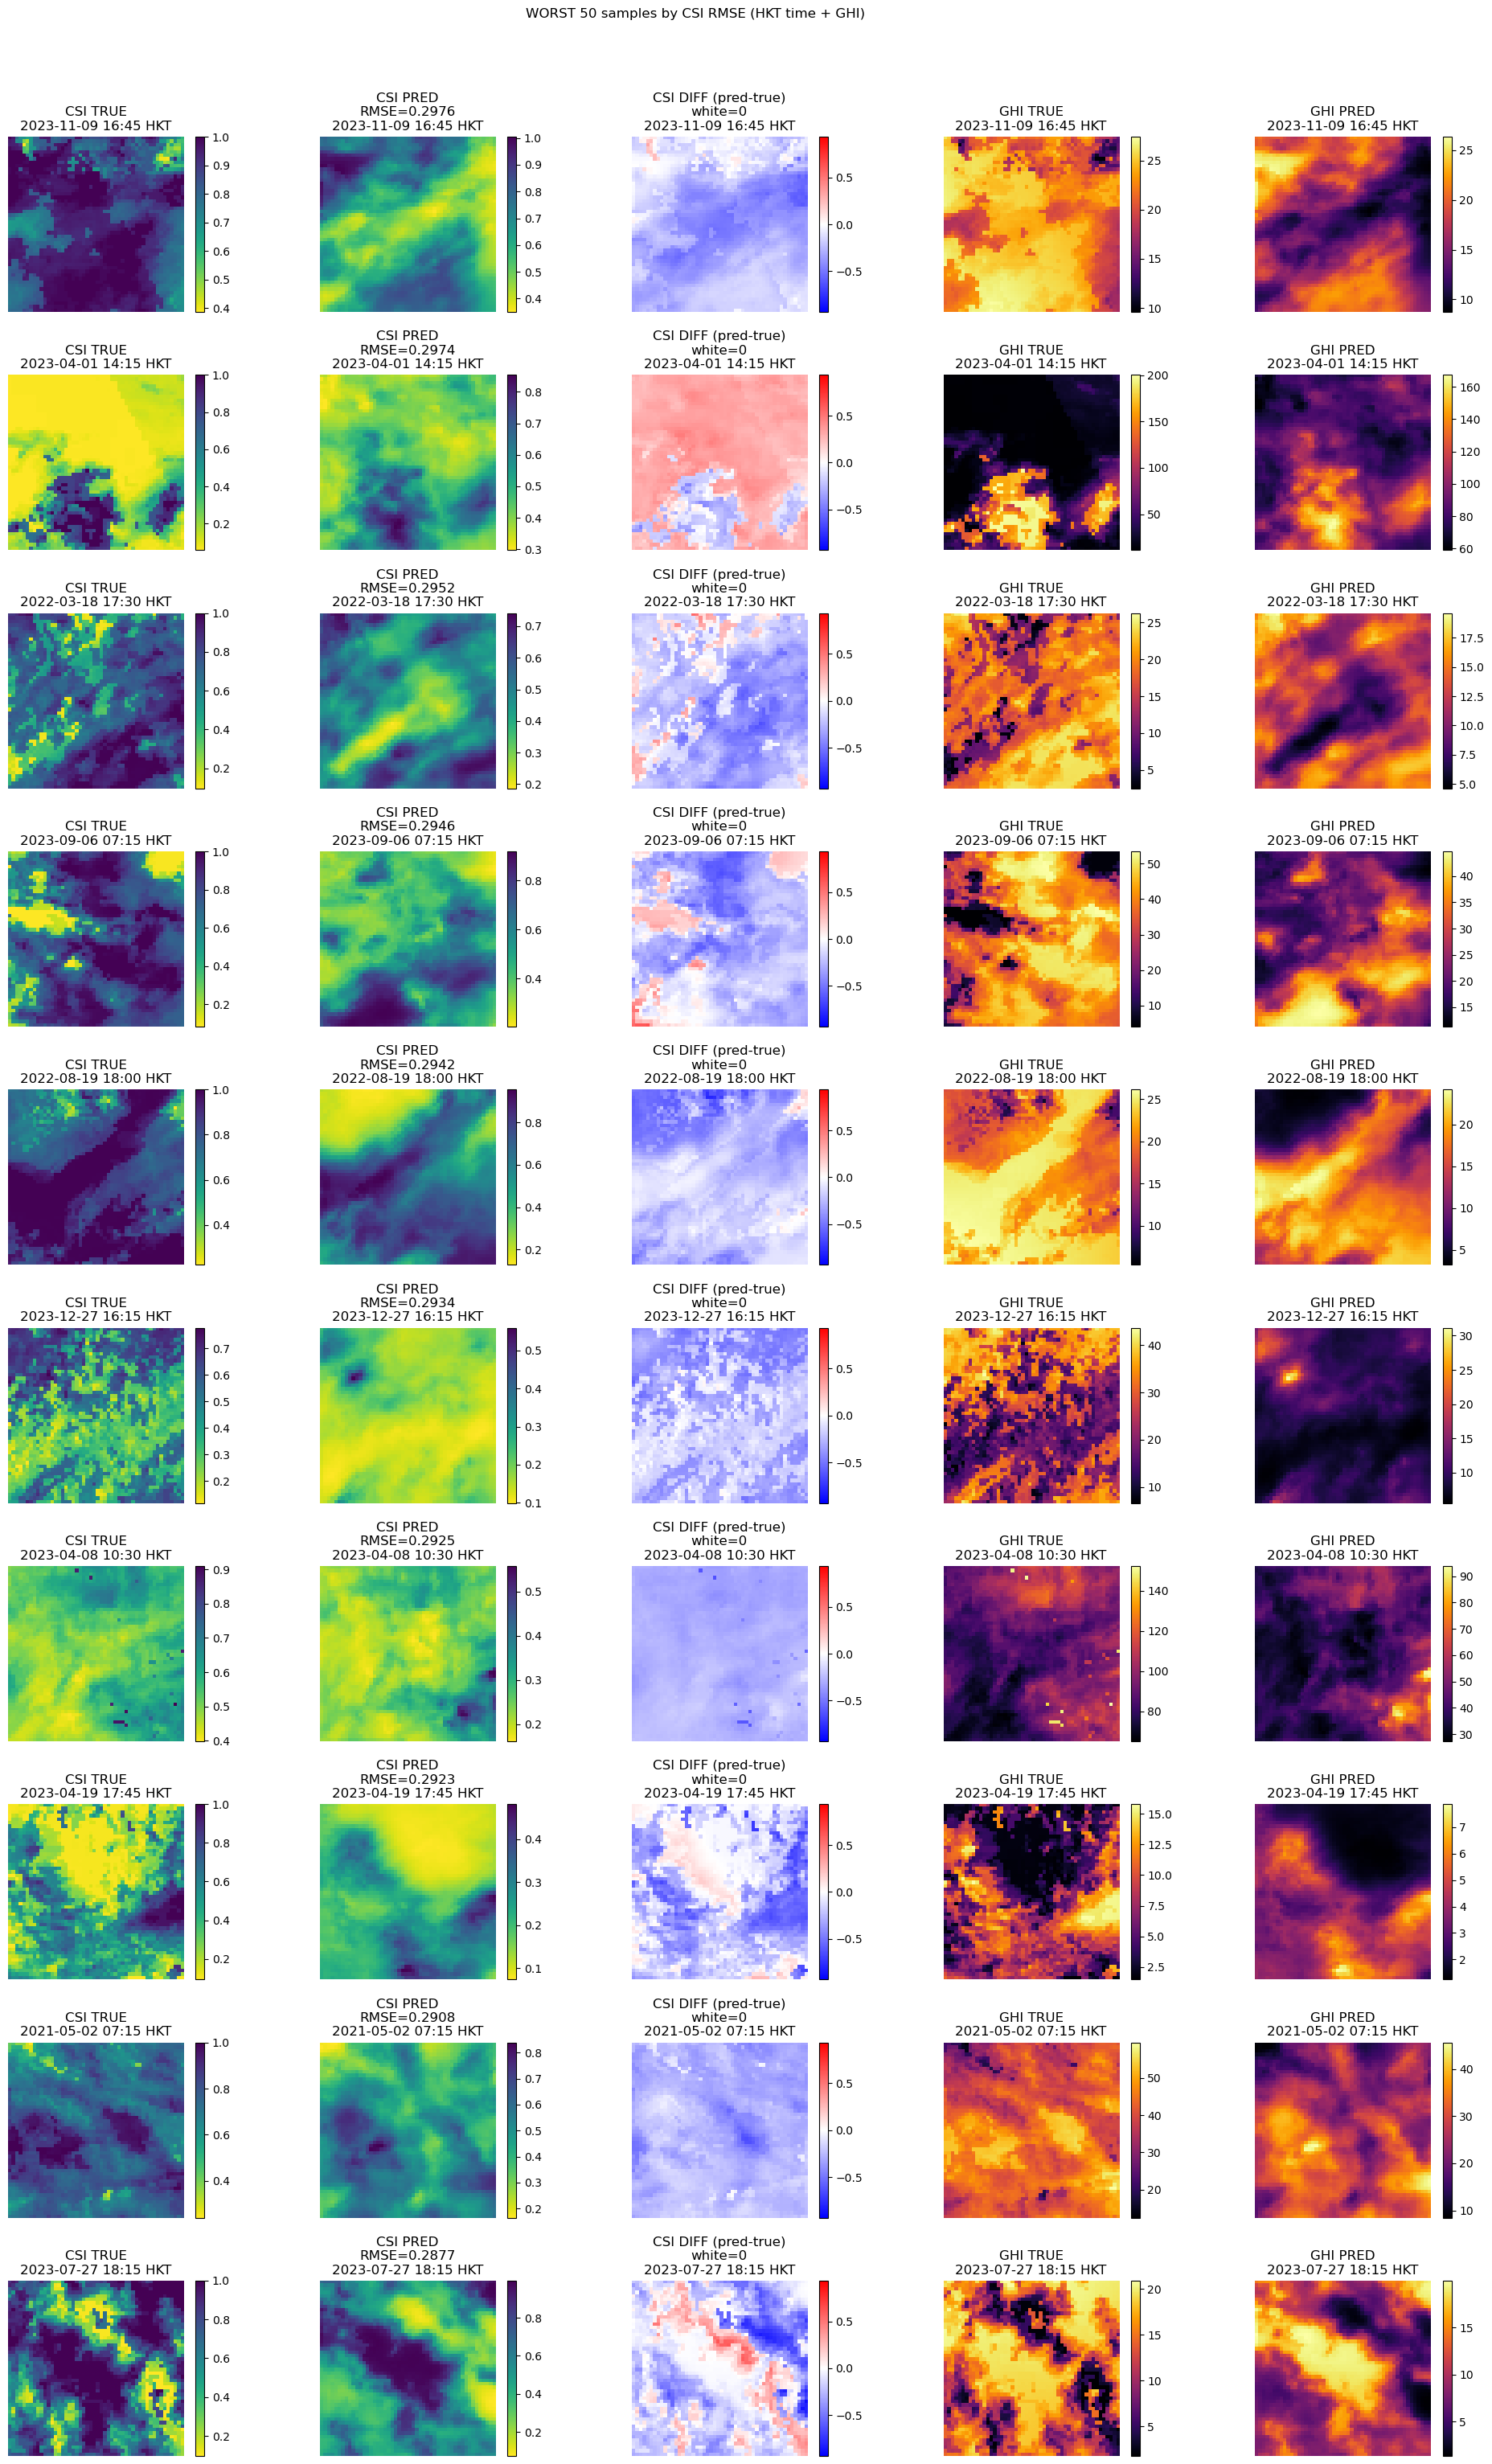

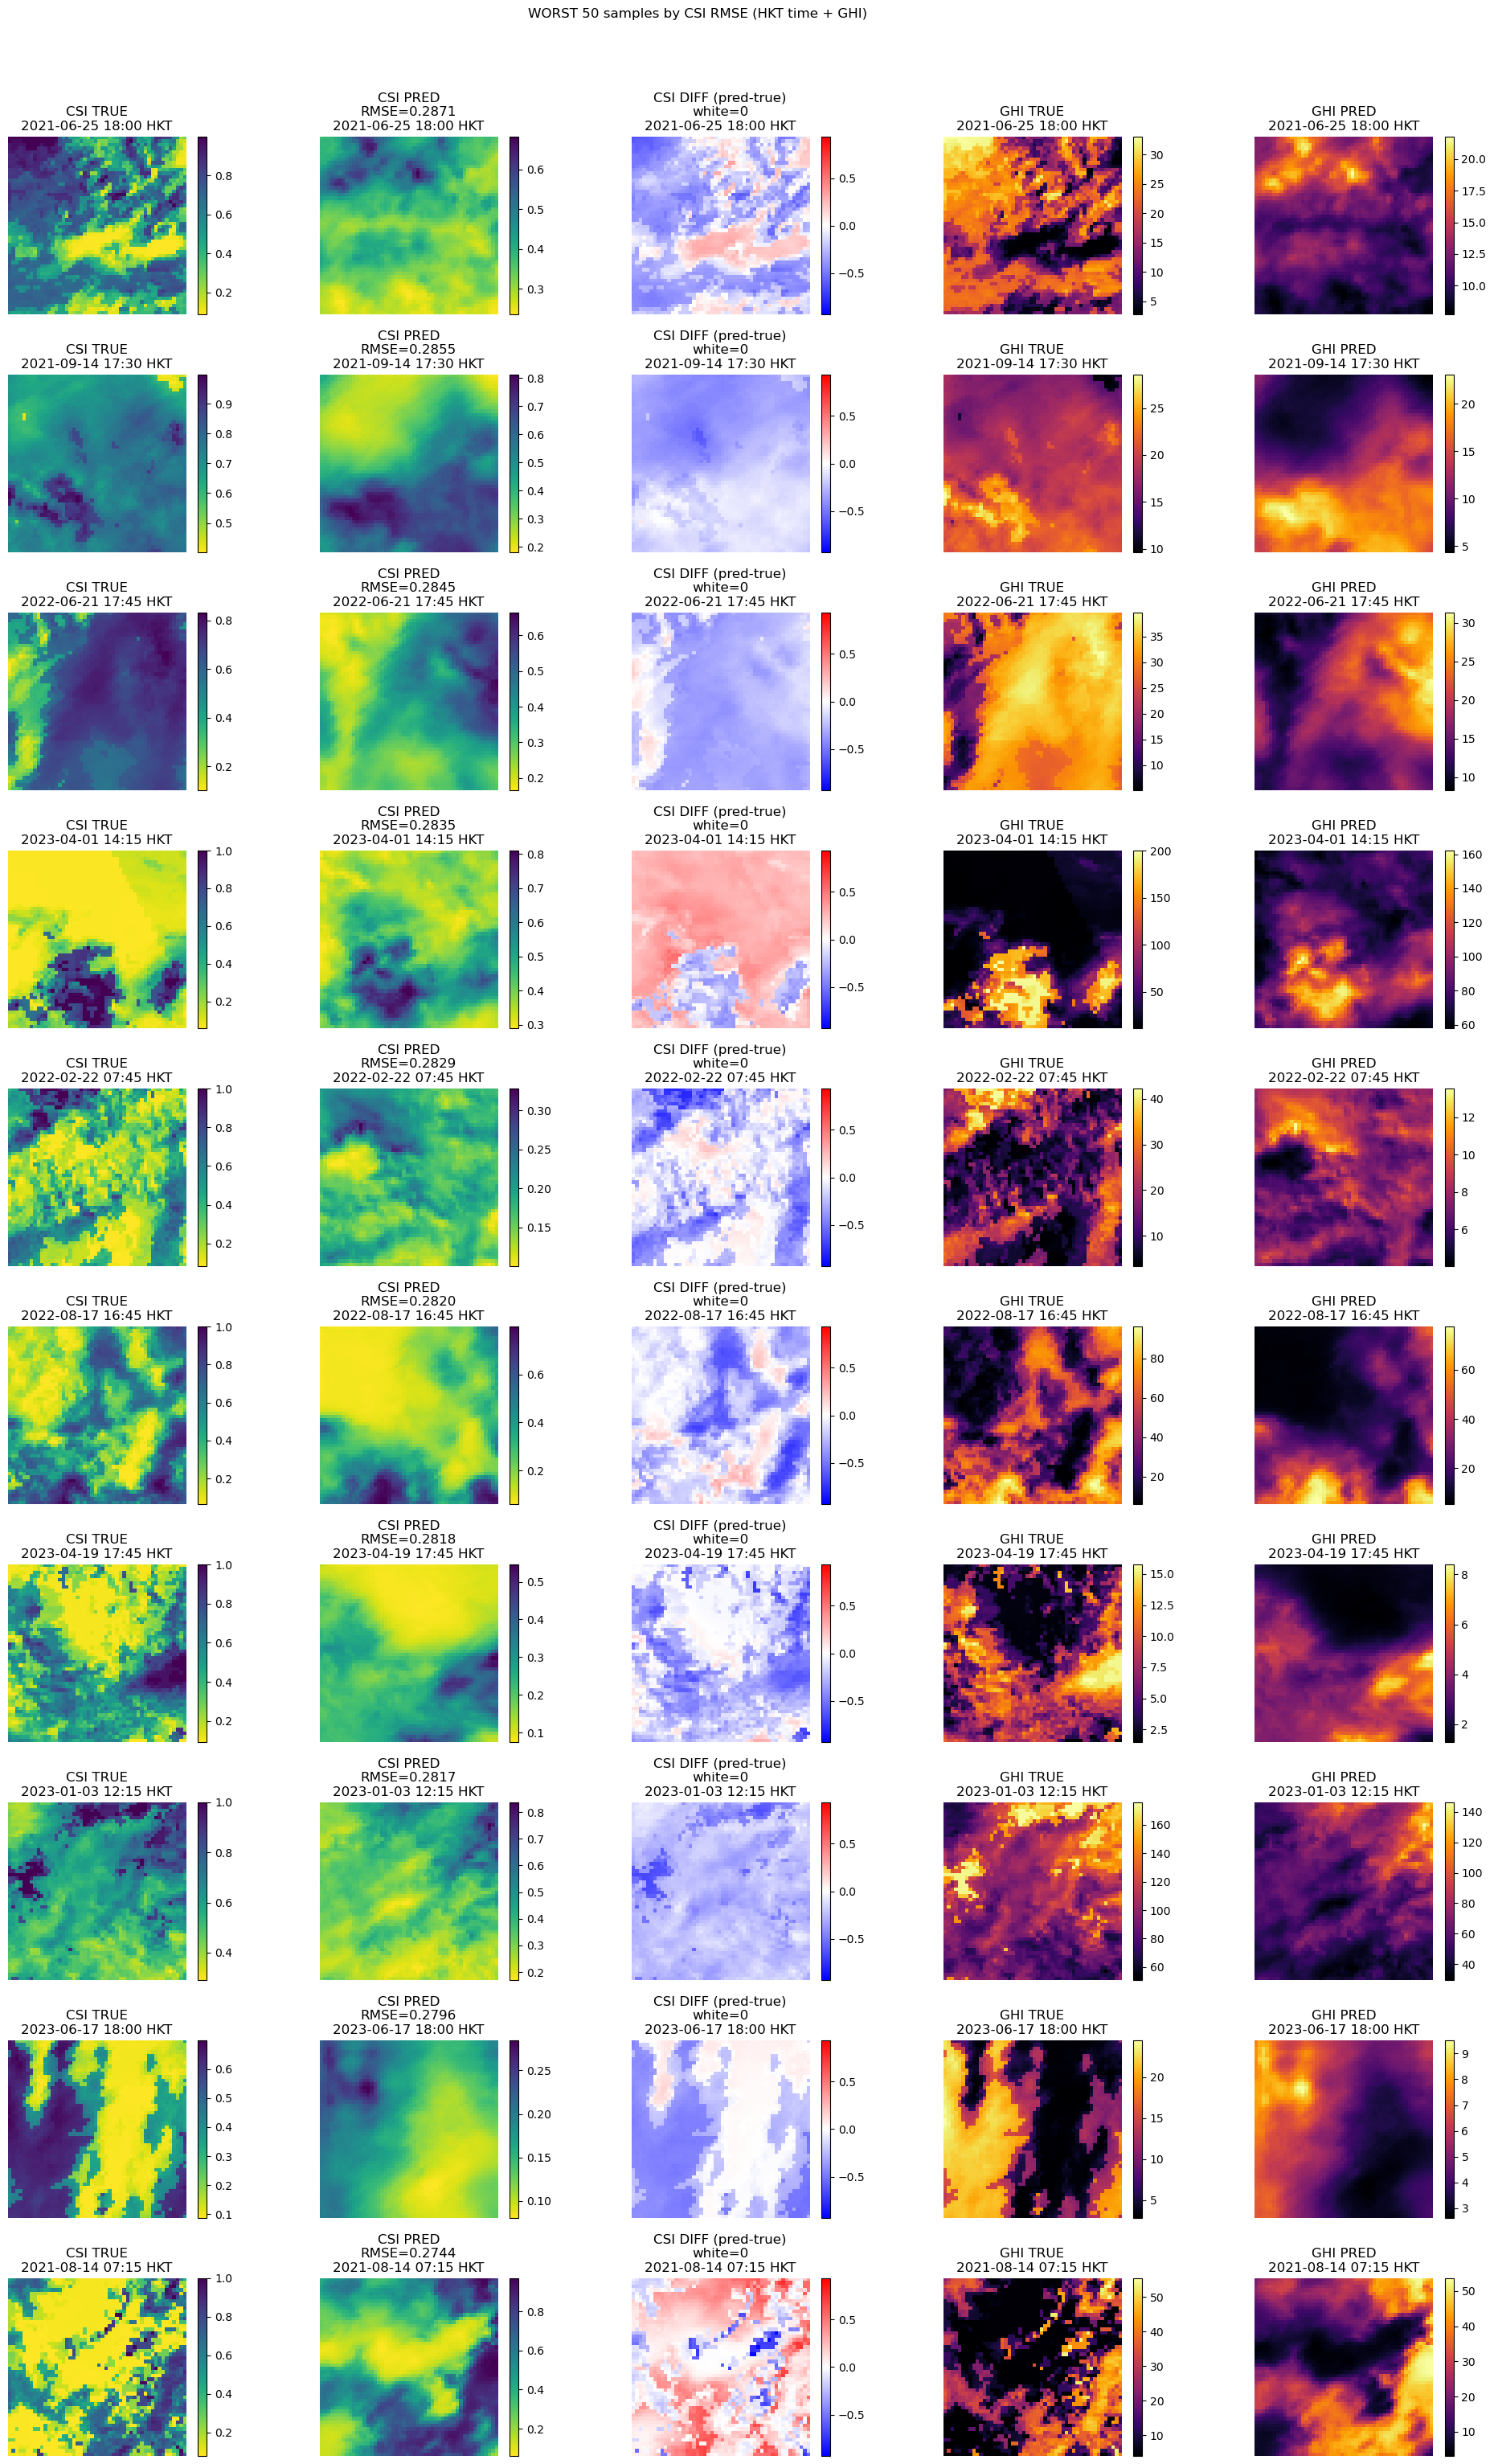

In [61]:
from src.plot import plot_rmse_extremes_with_time_and_ghi
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="worst",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)


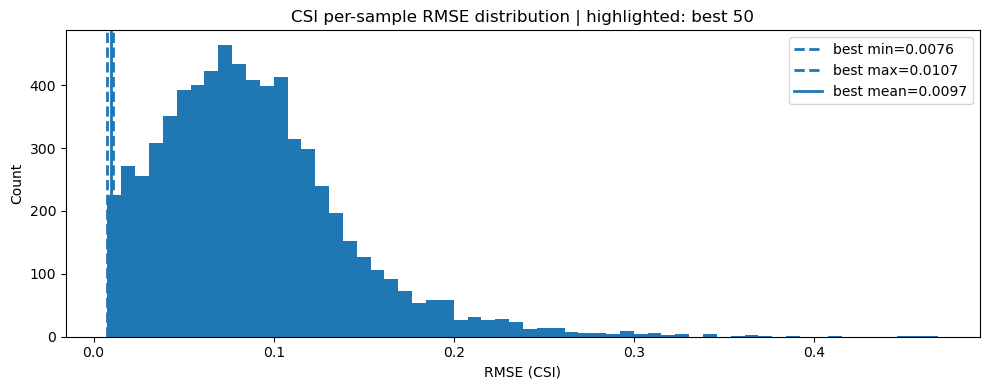

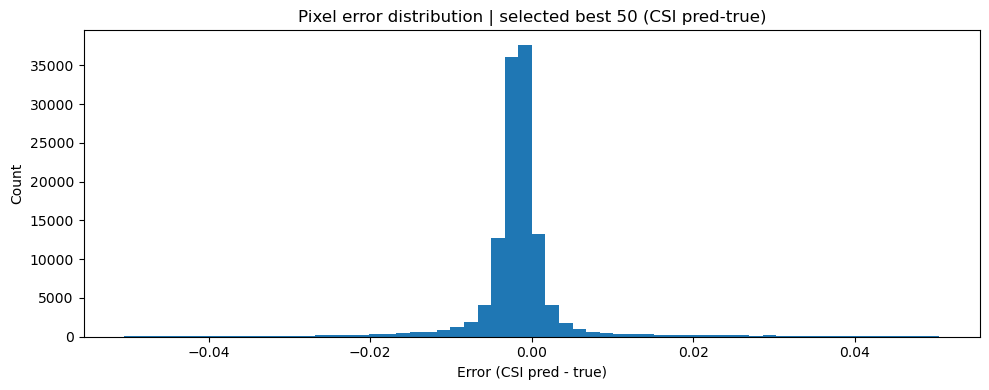

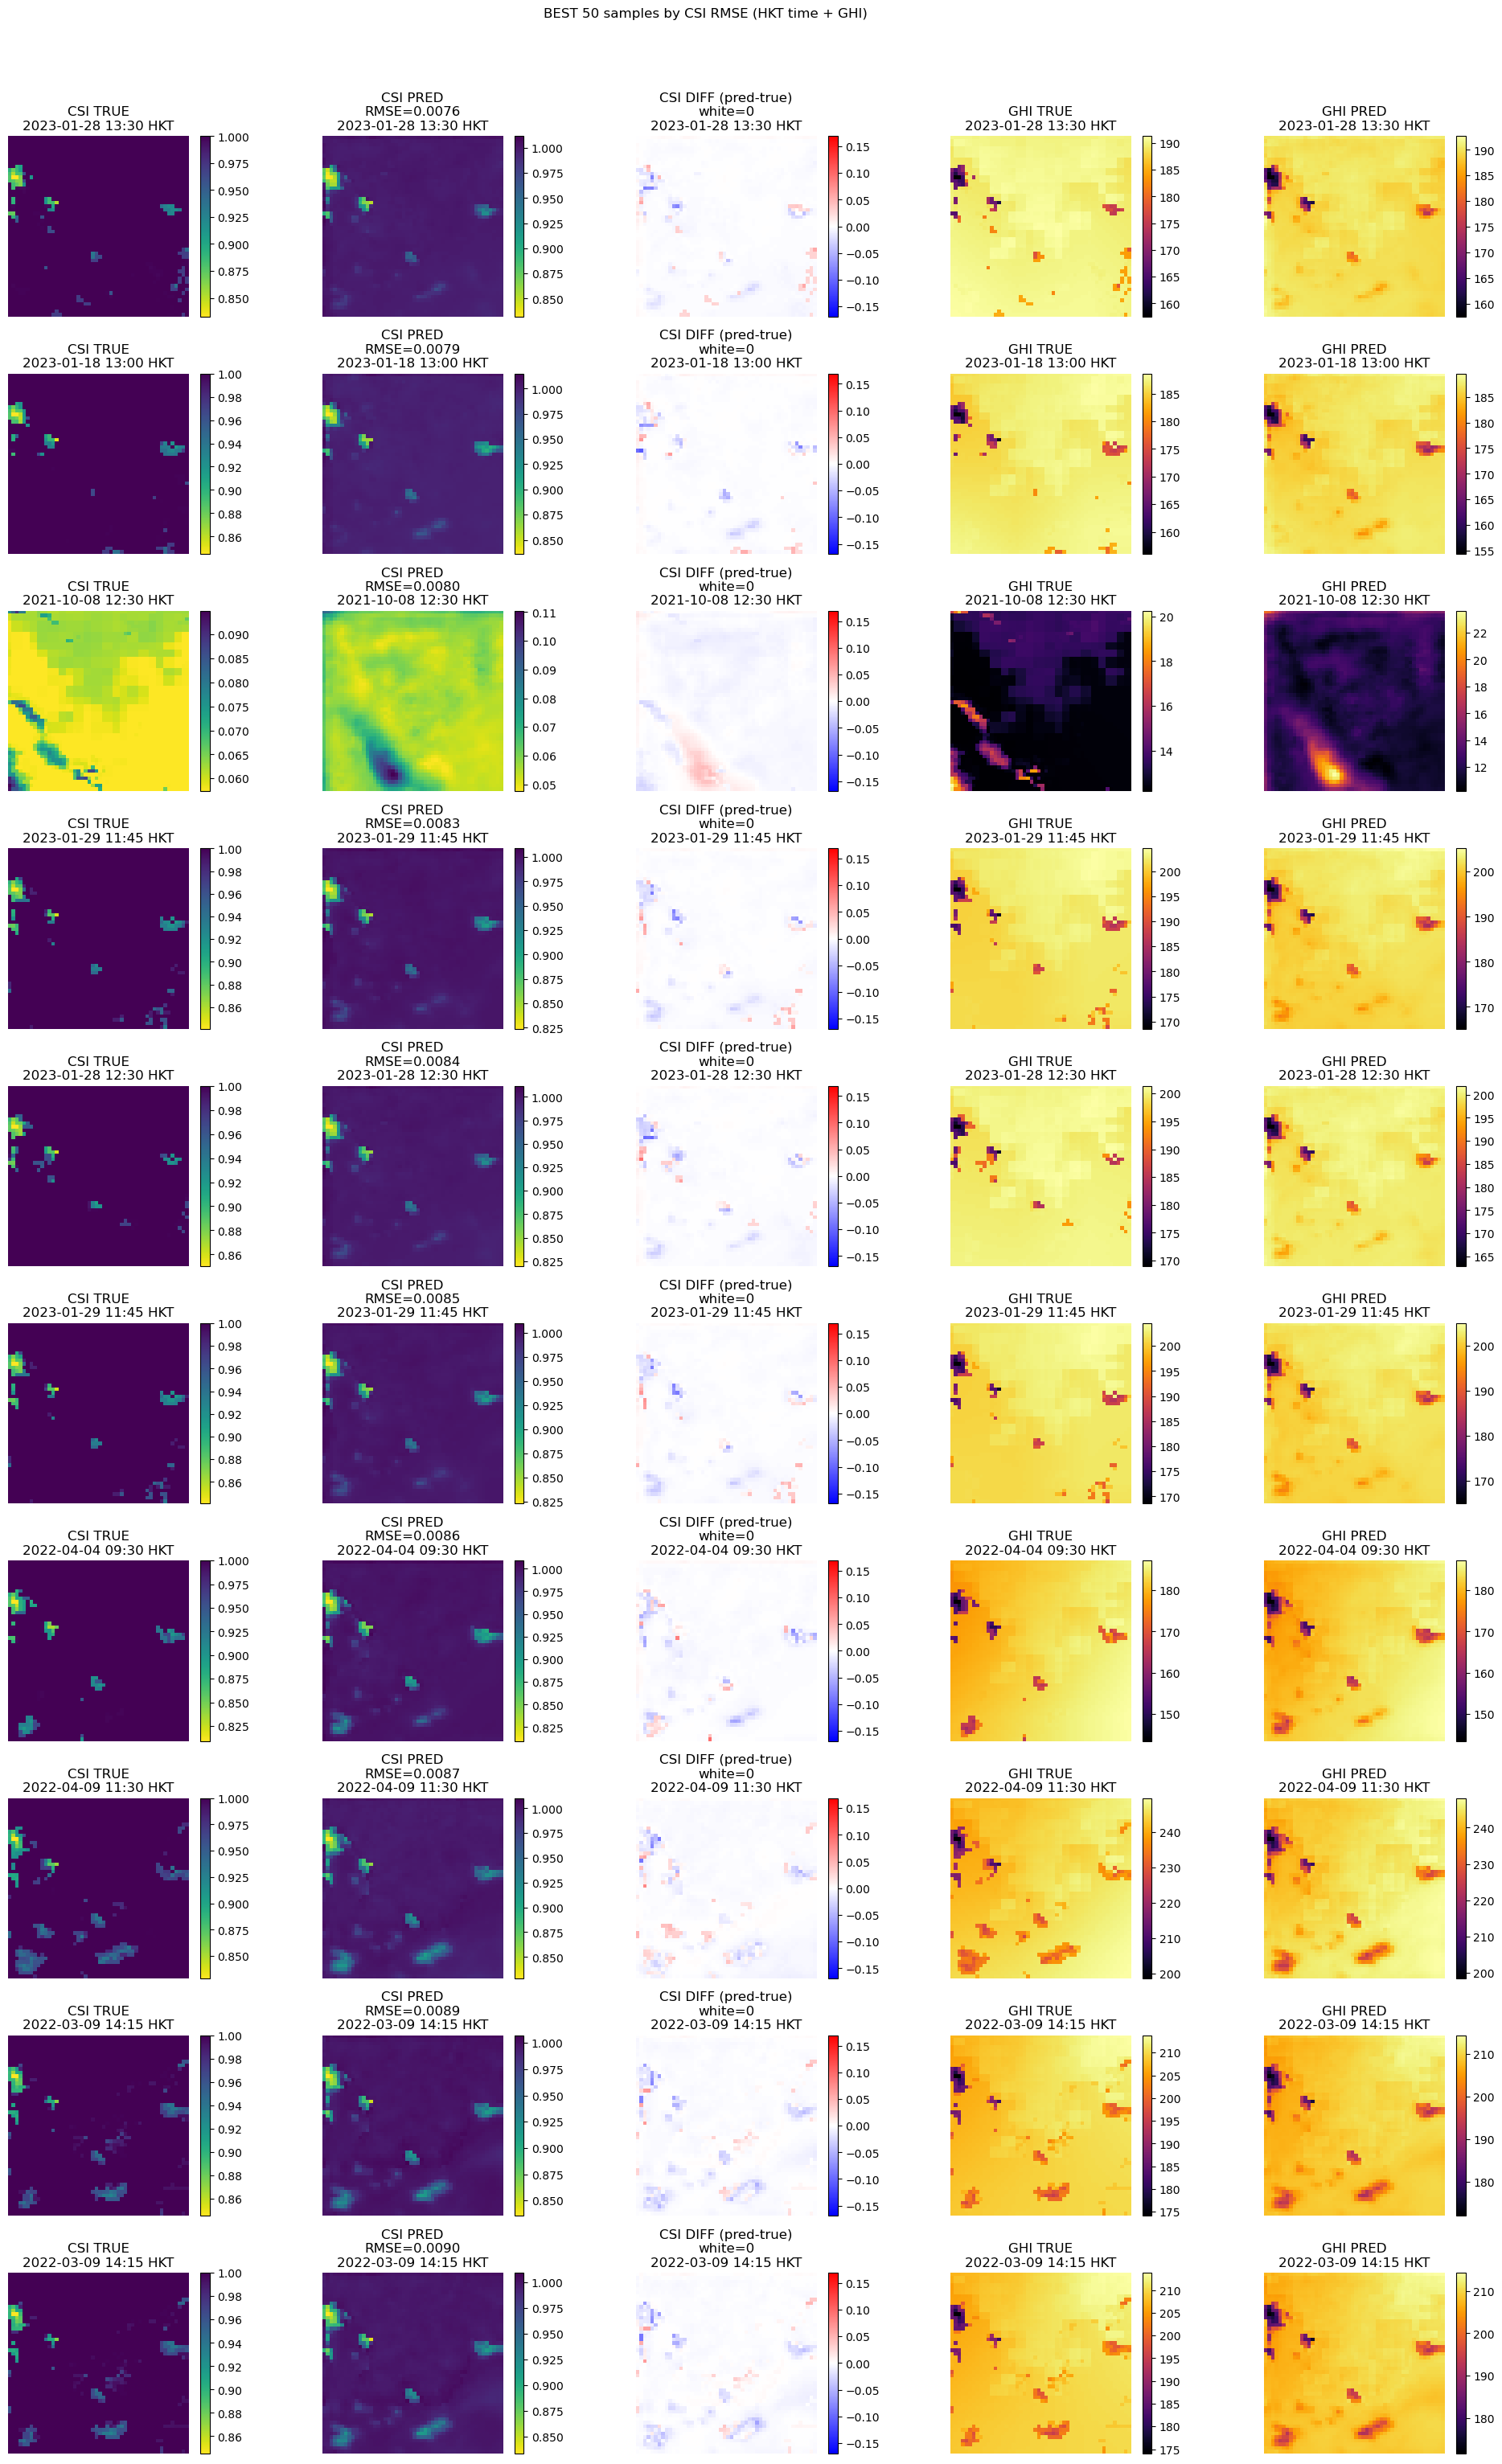

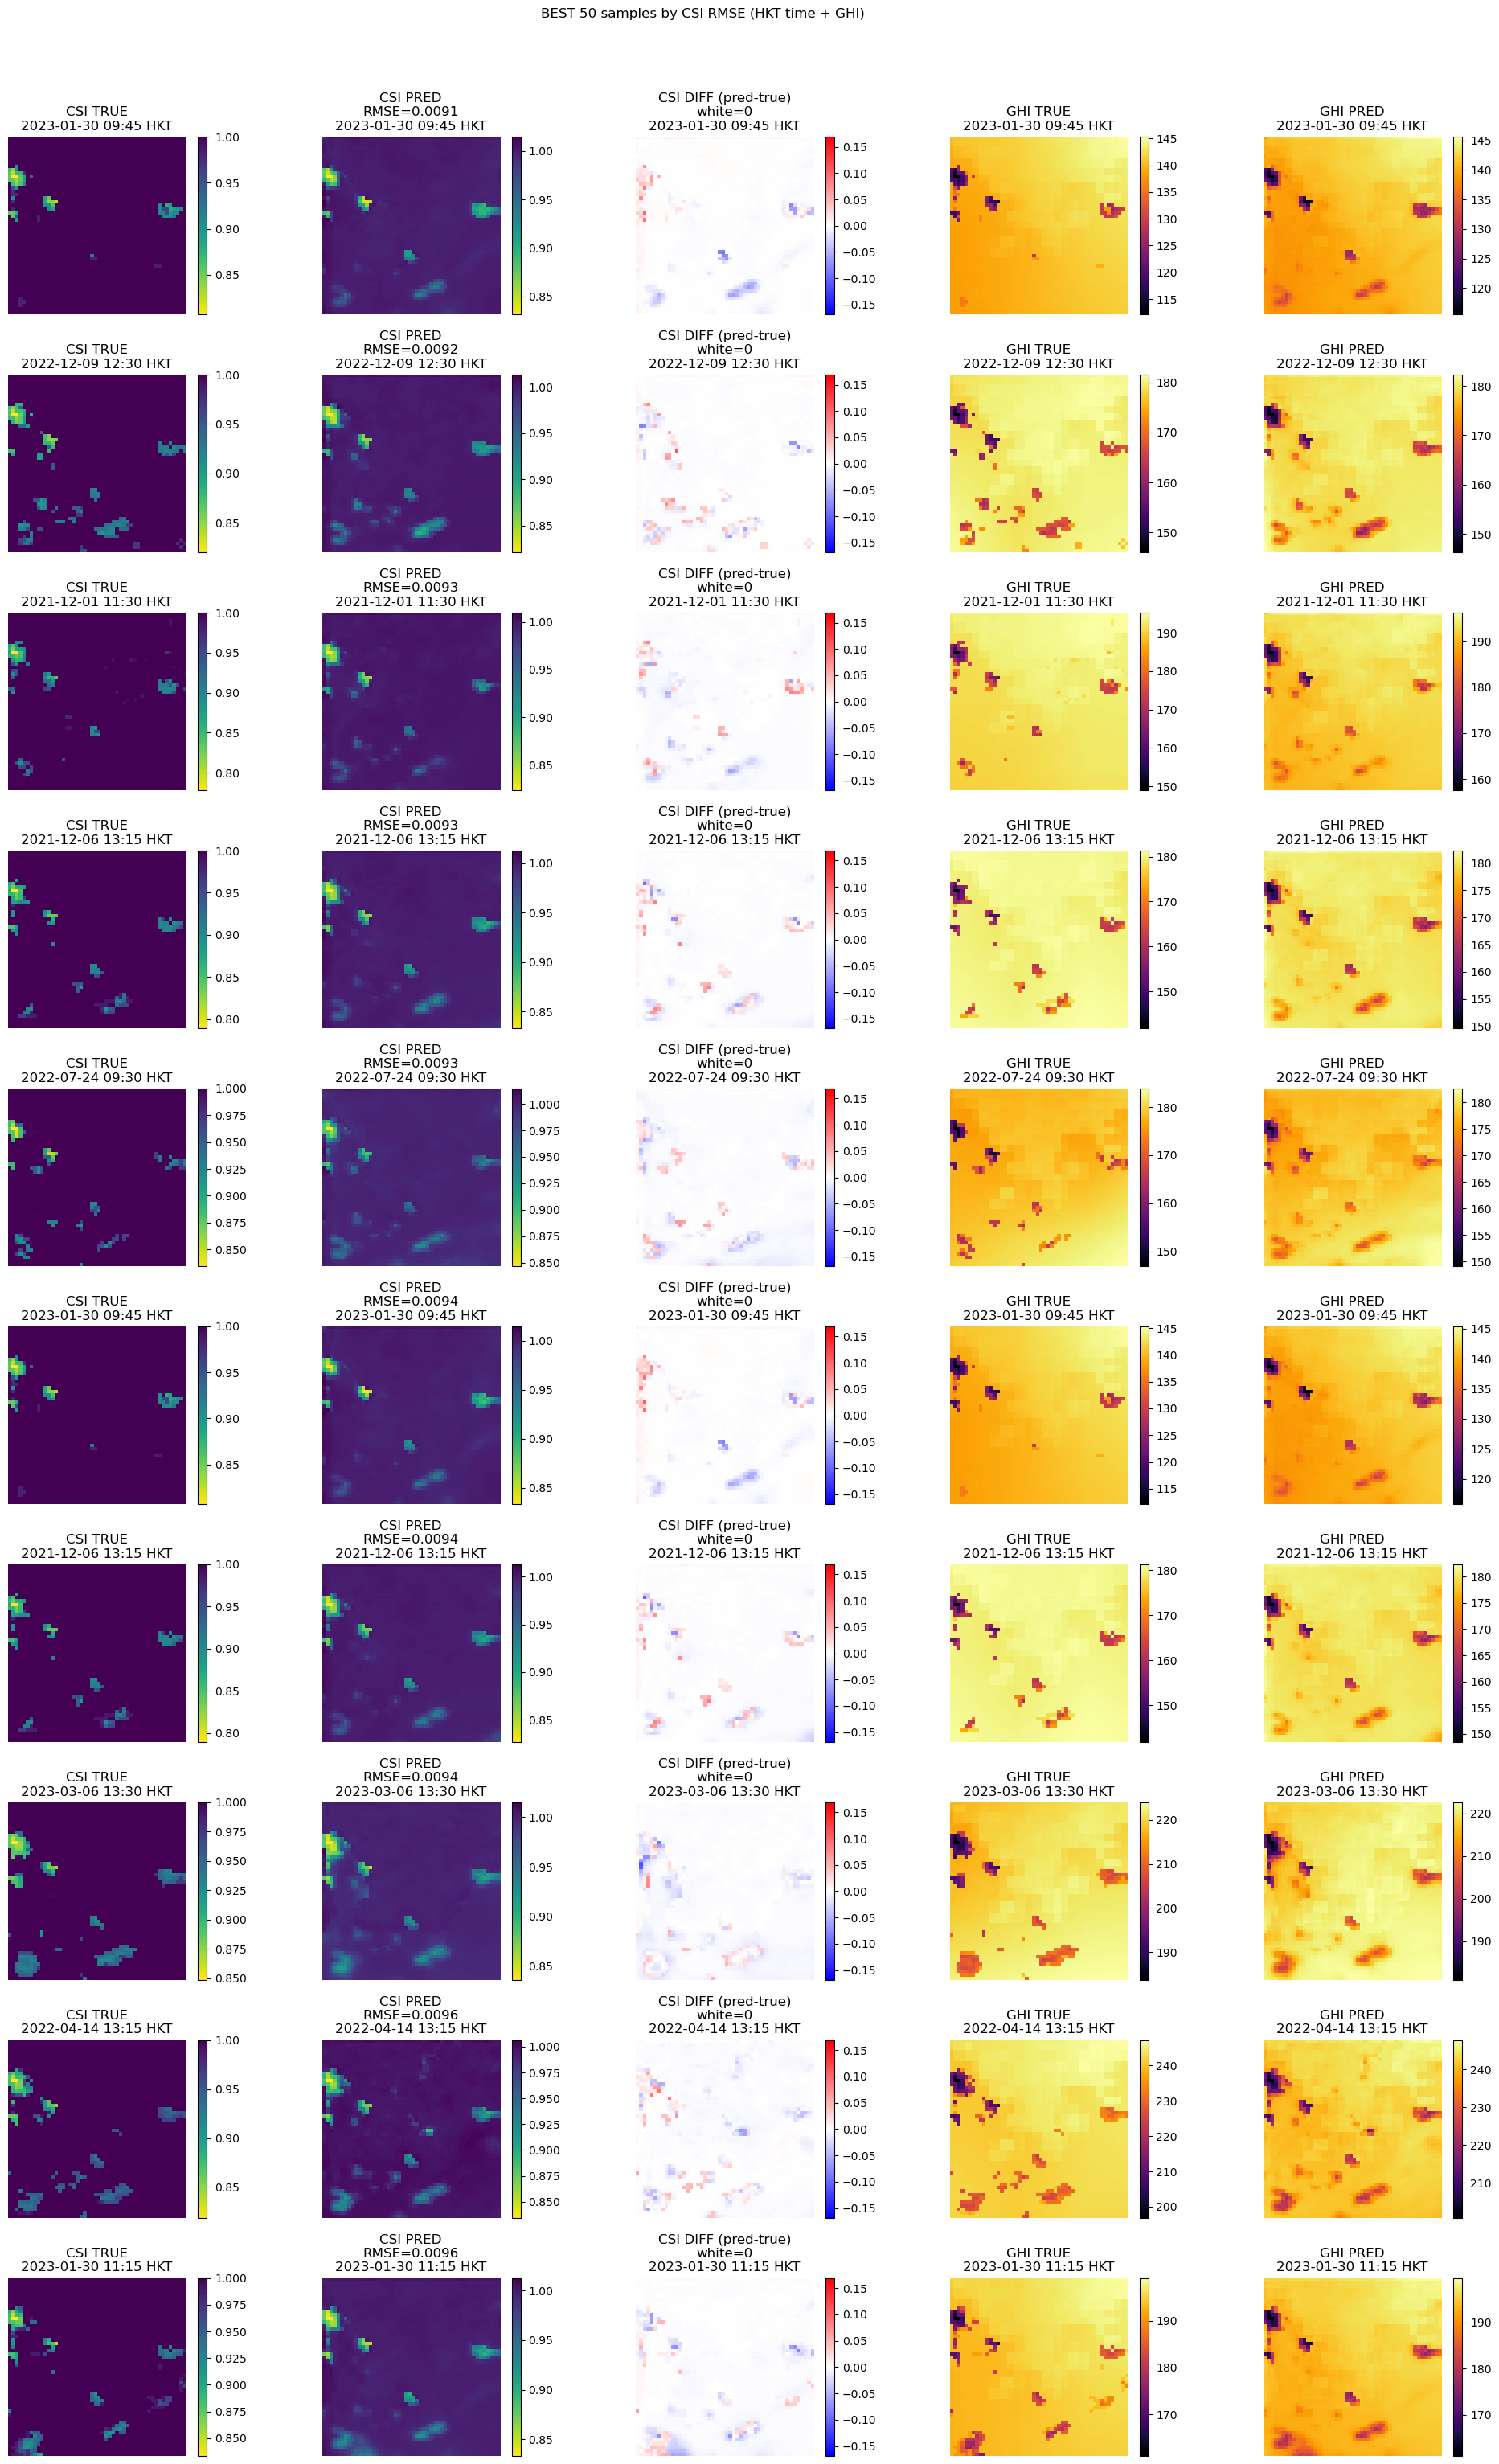

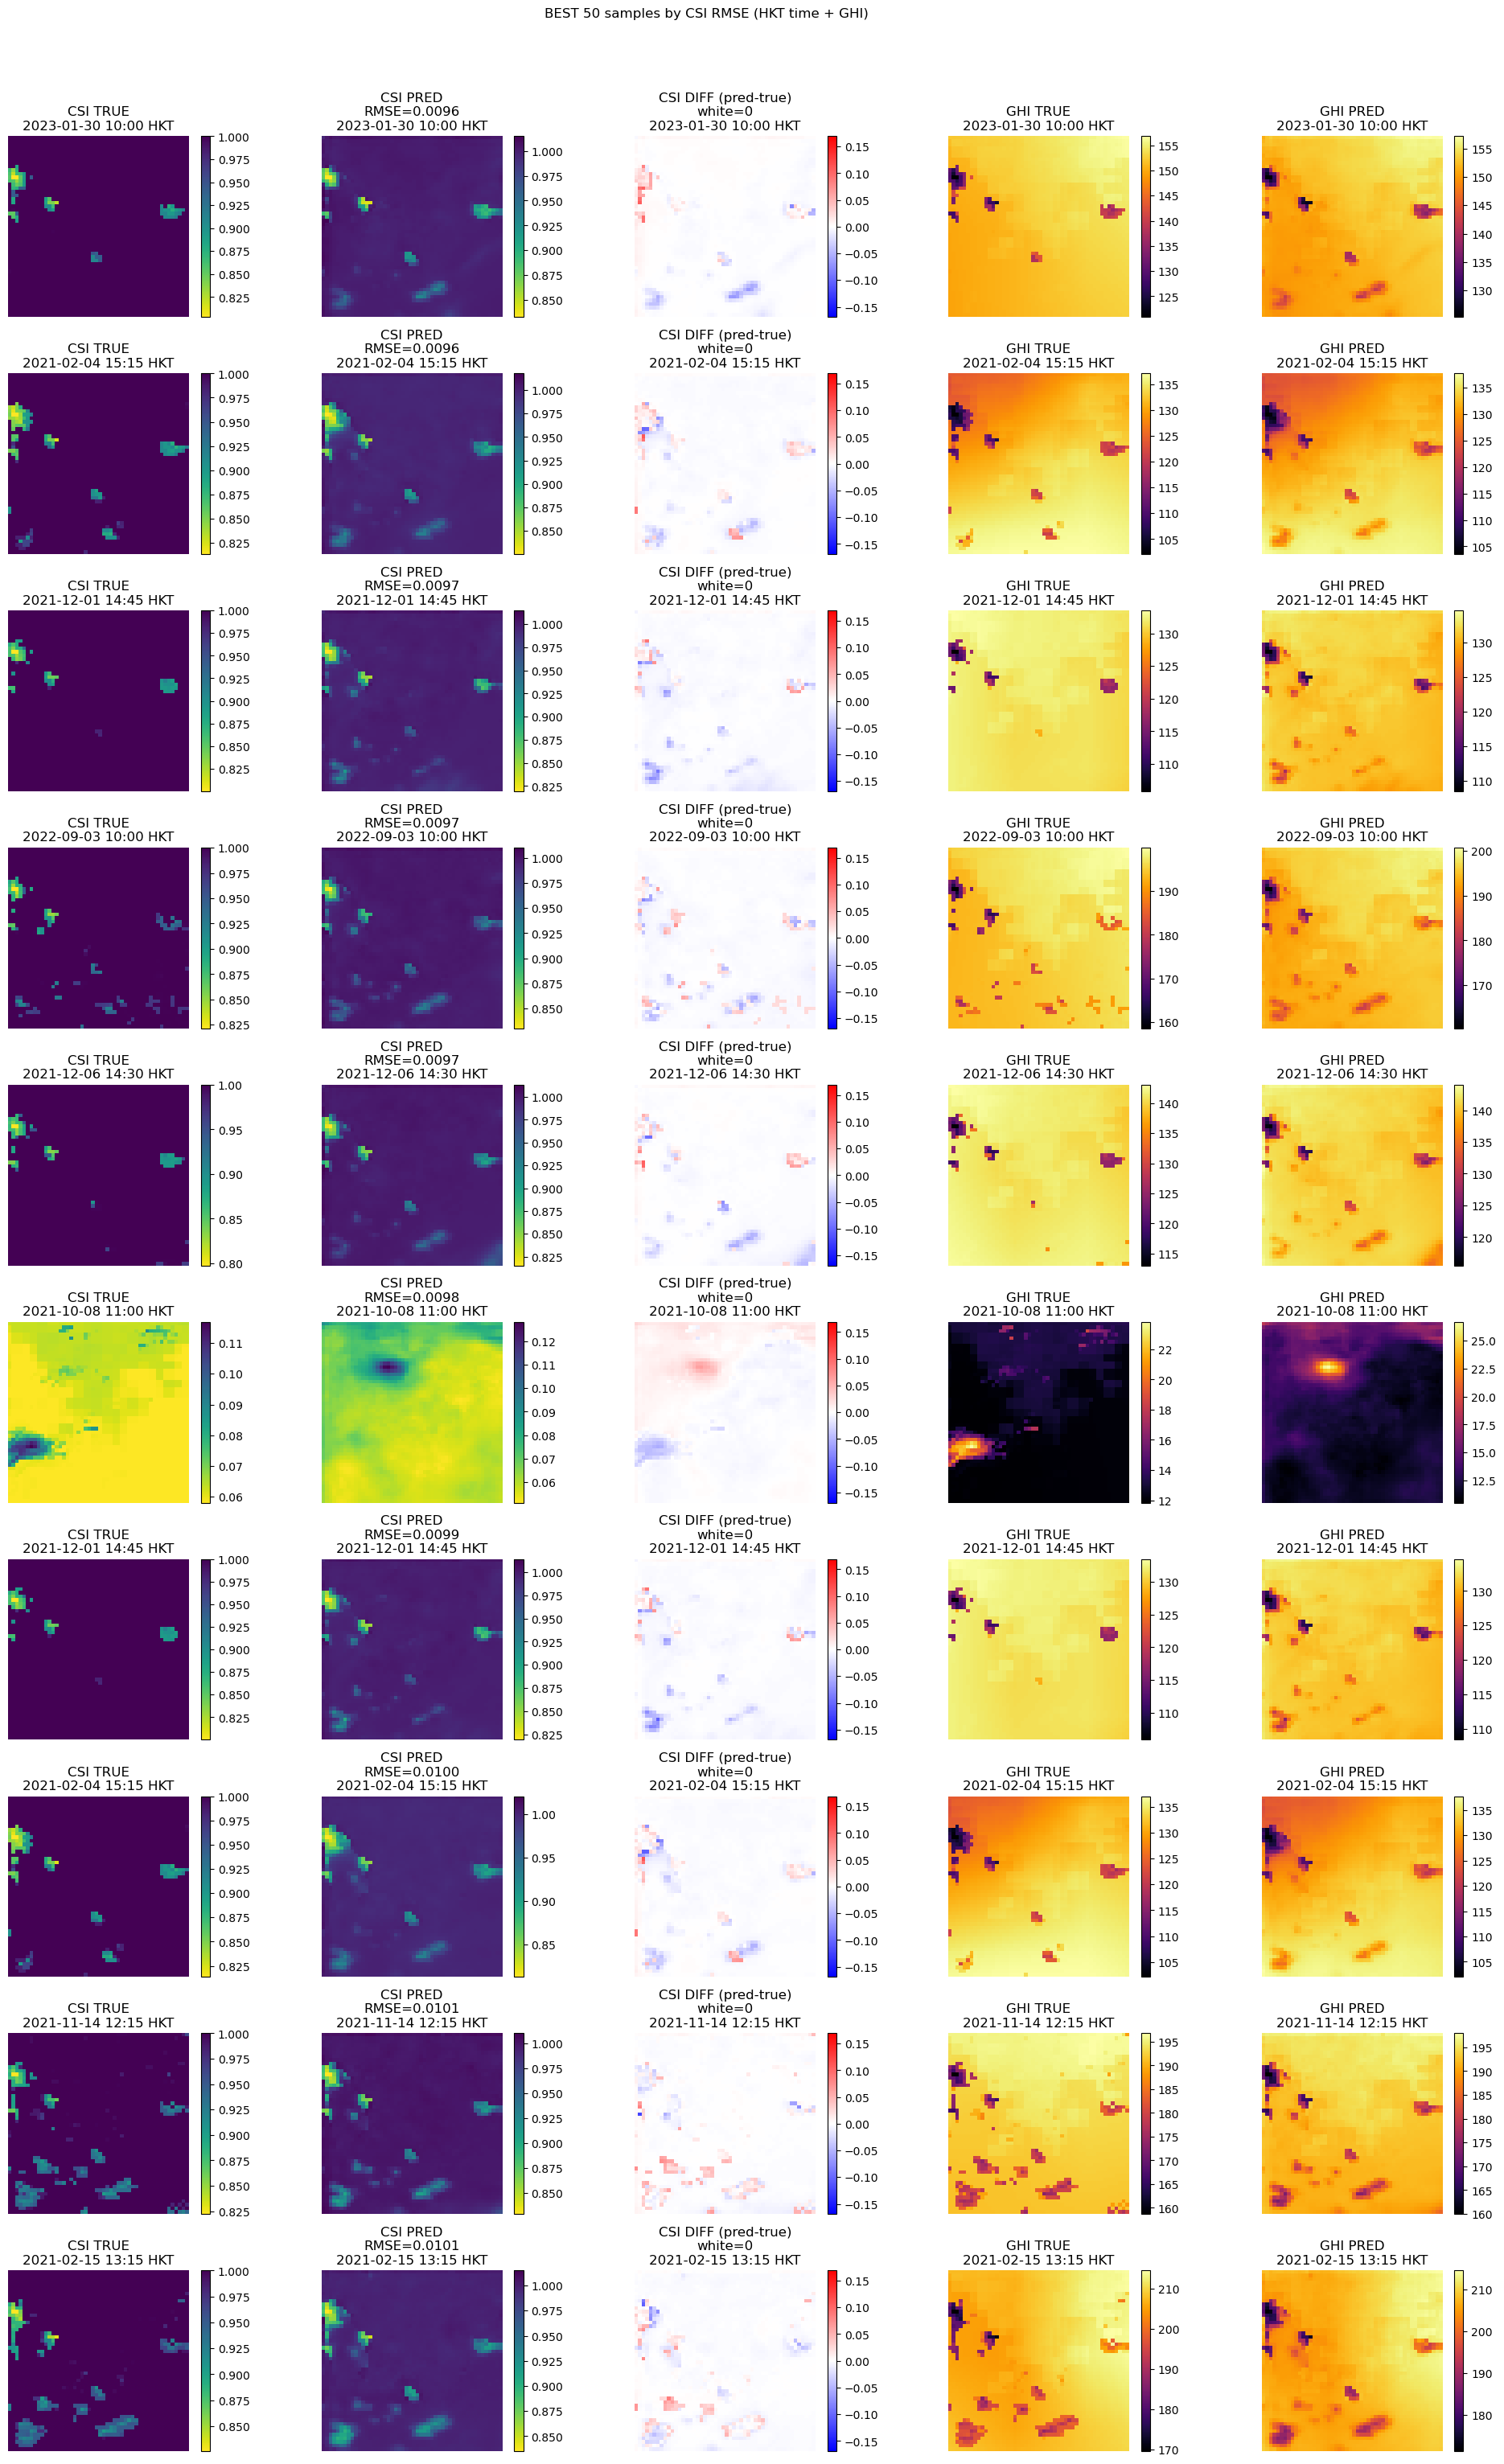

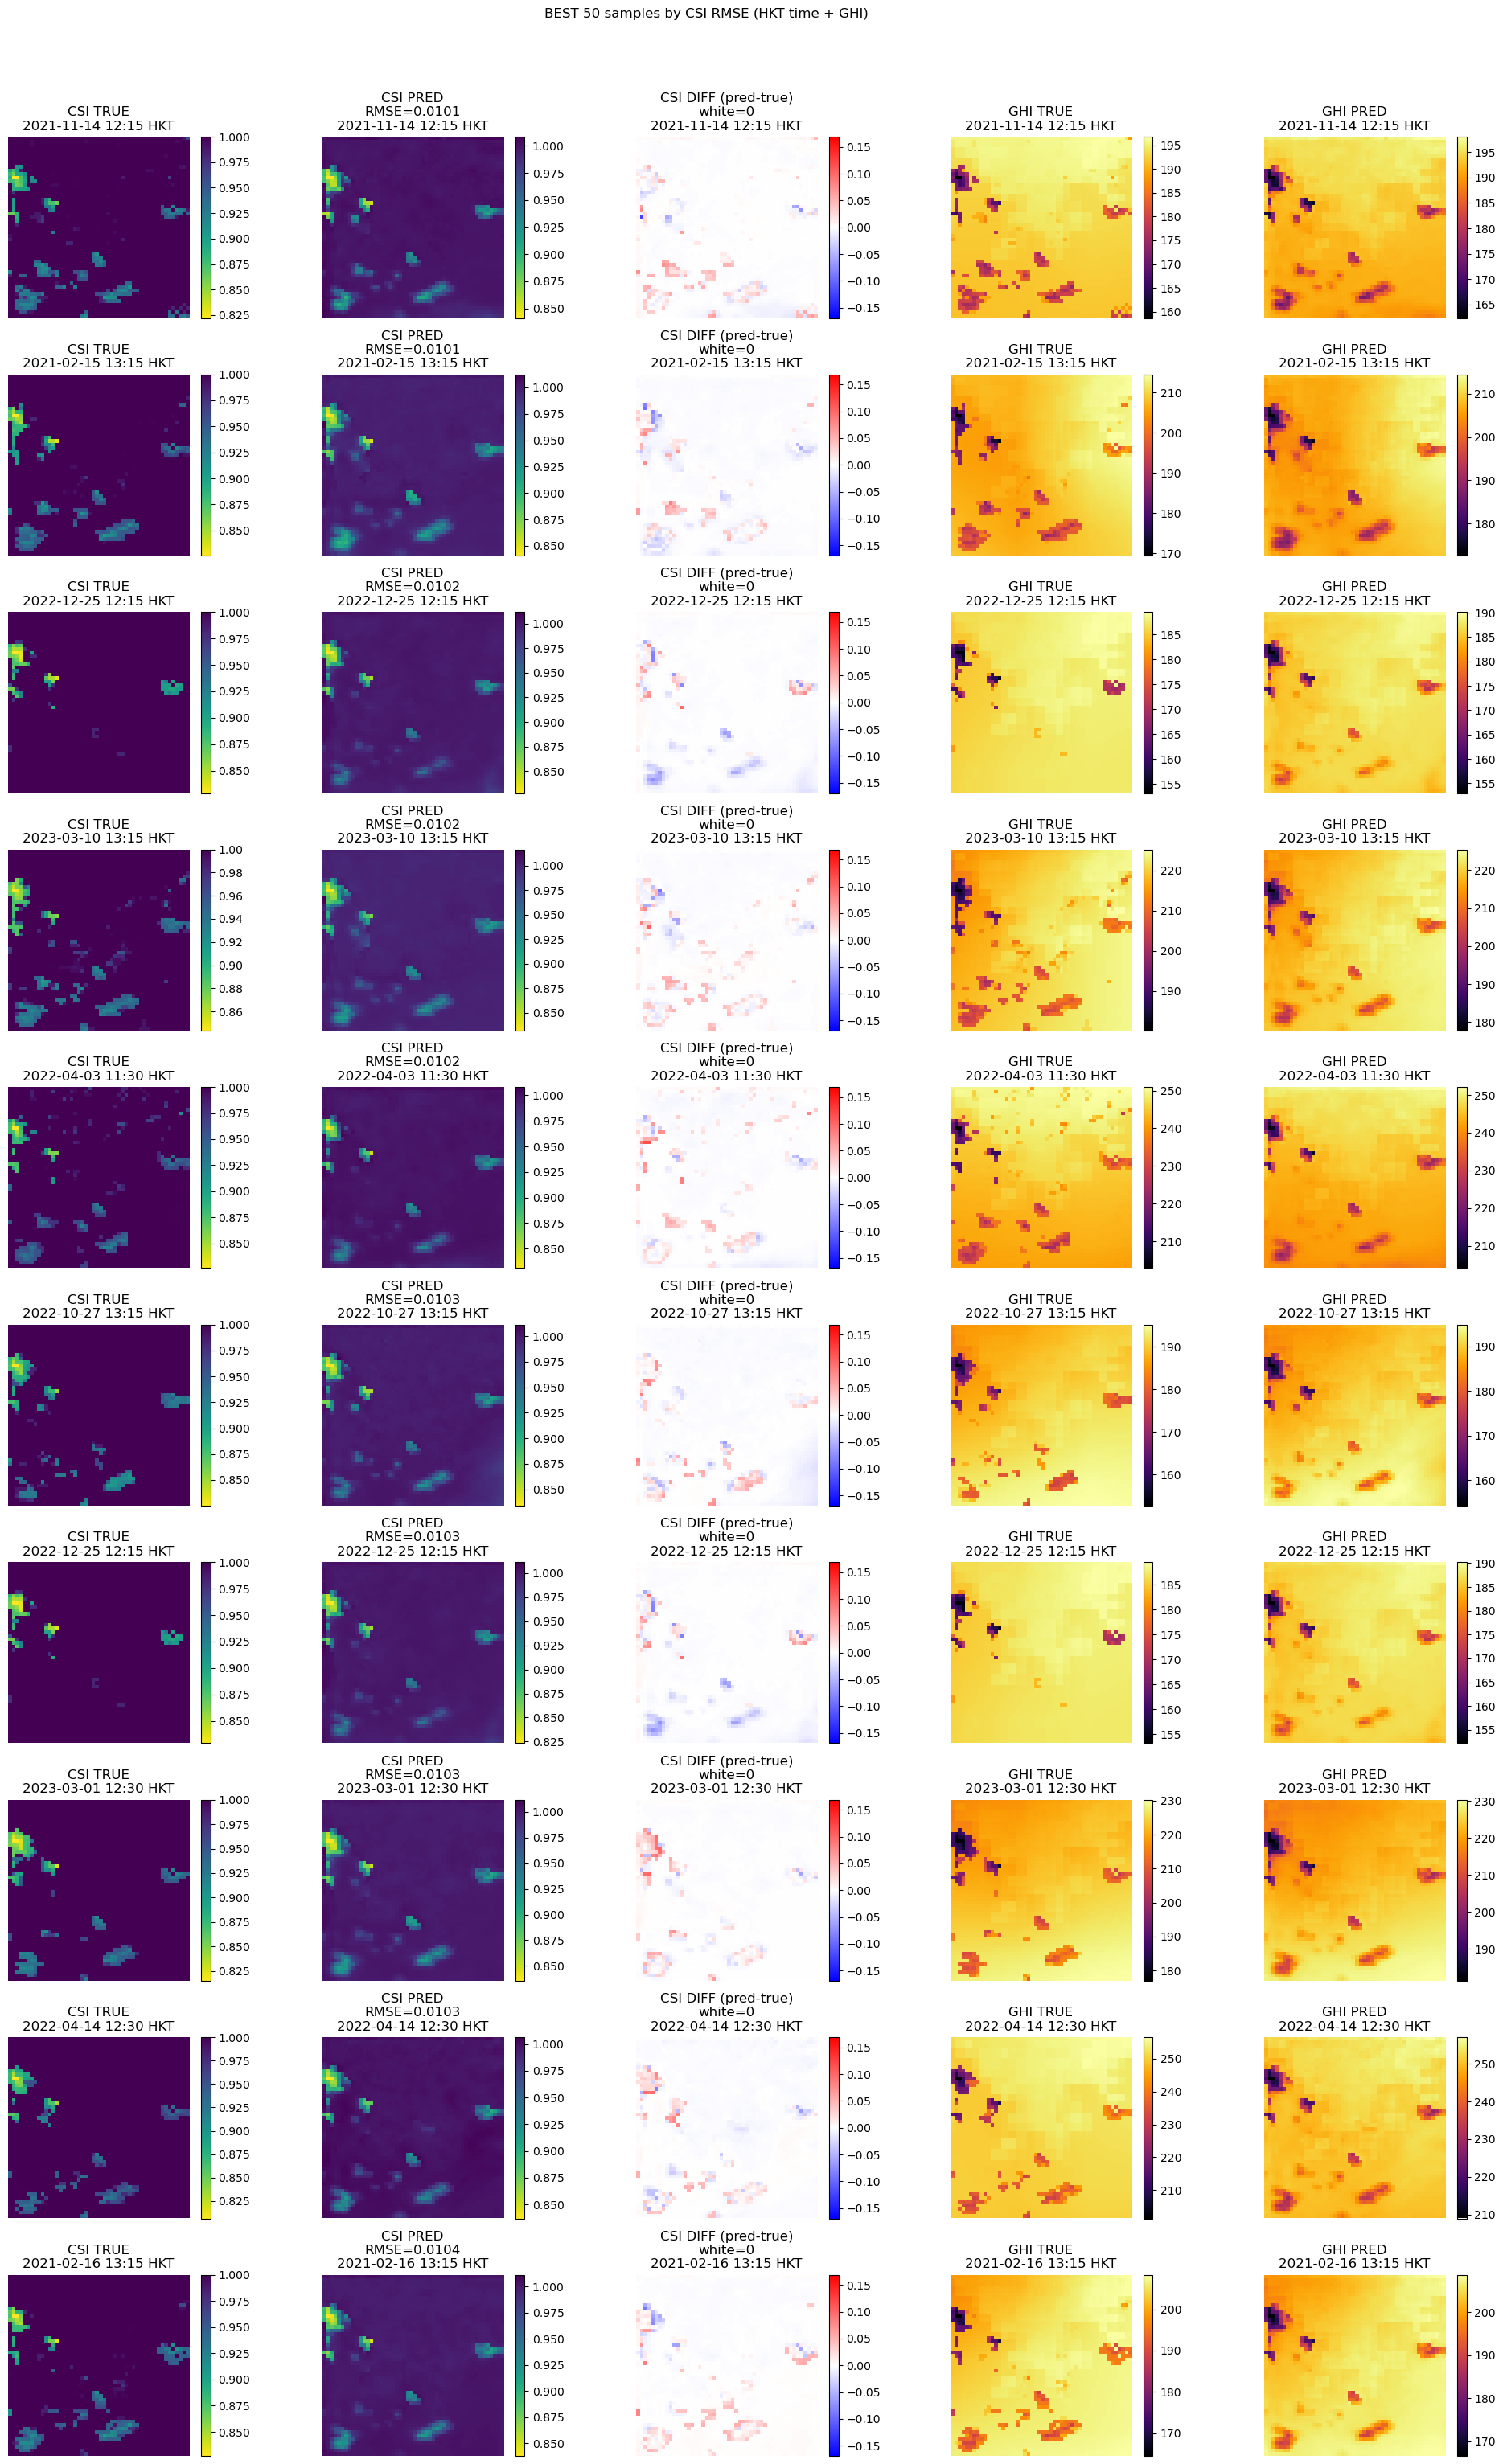

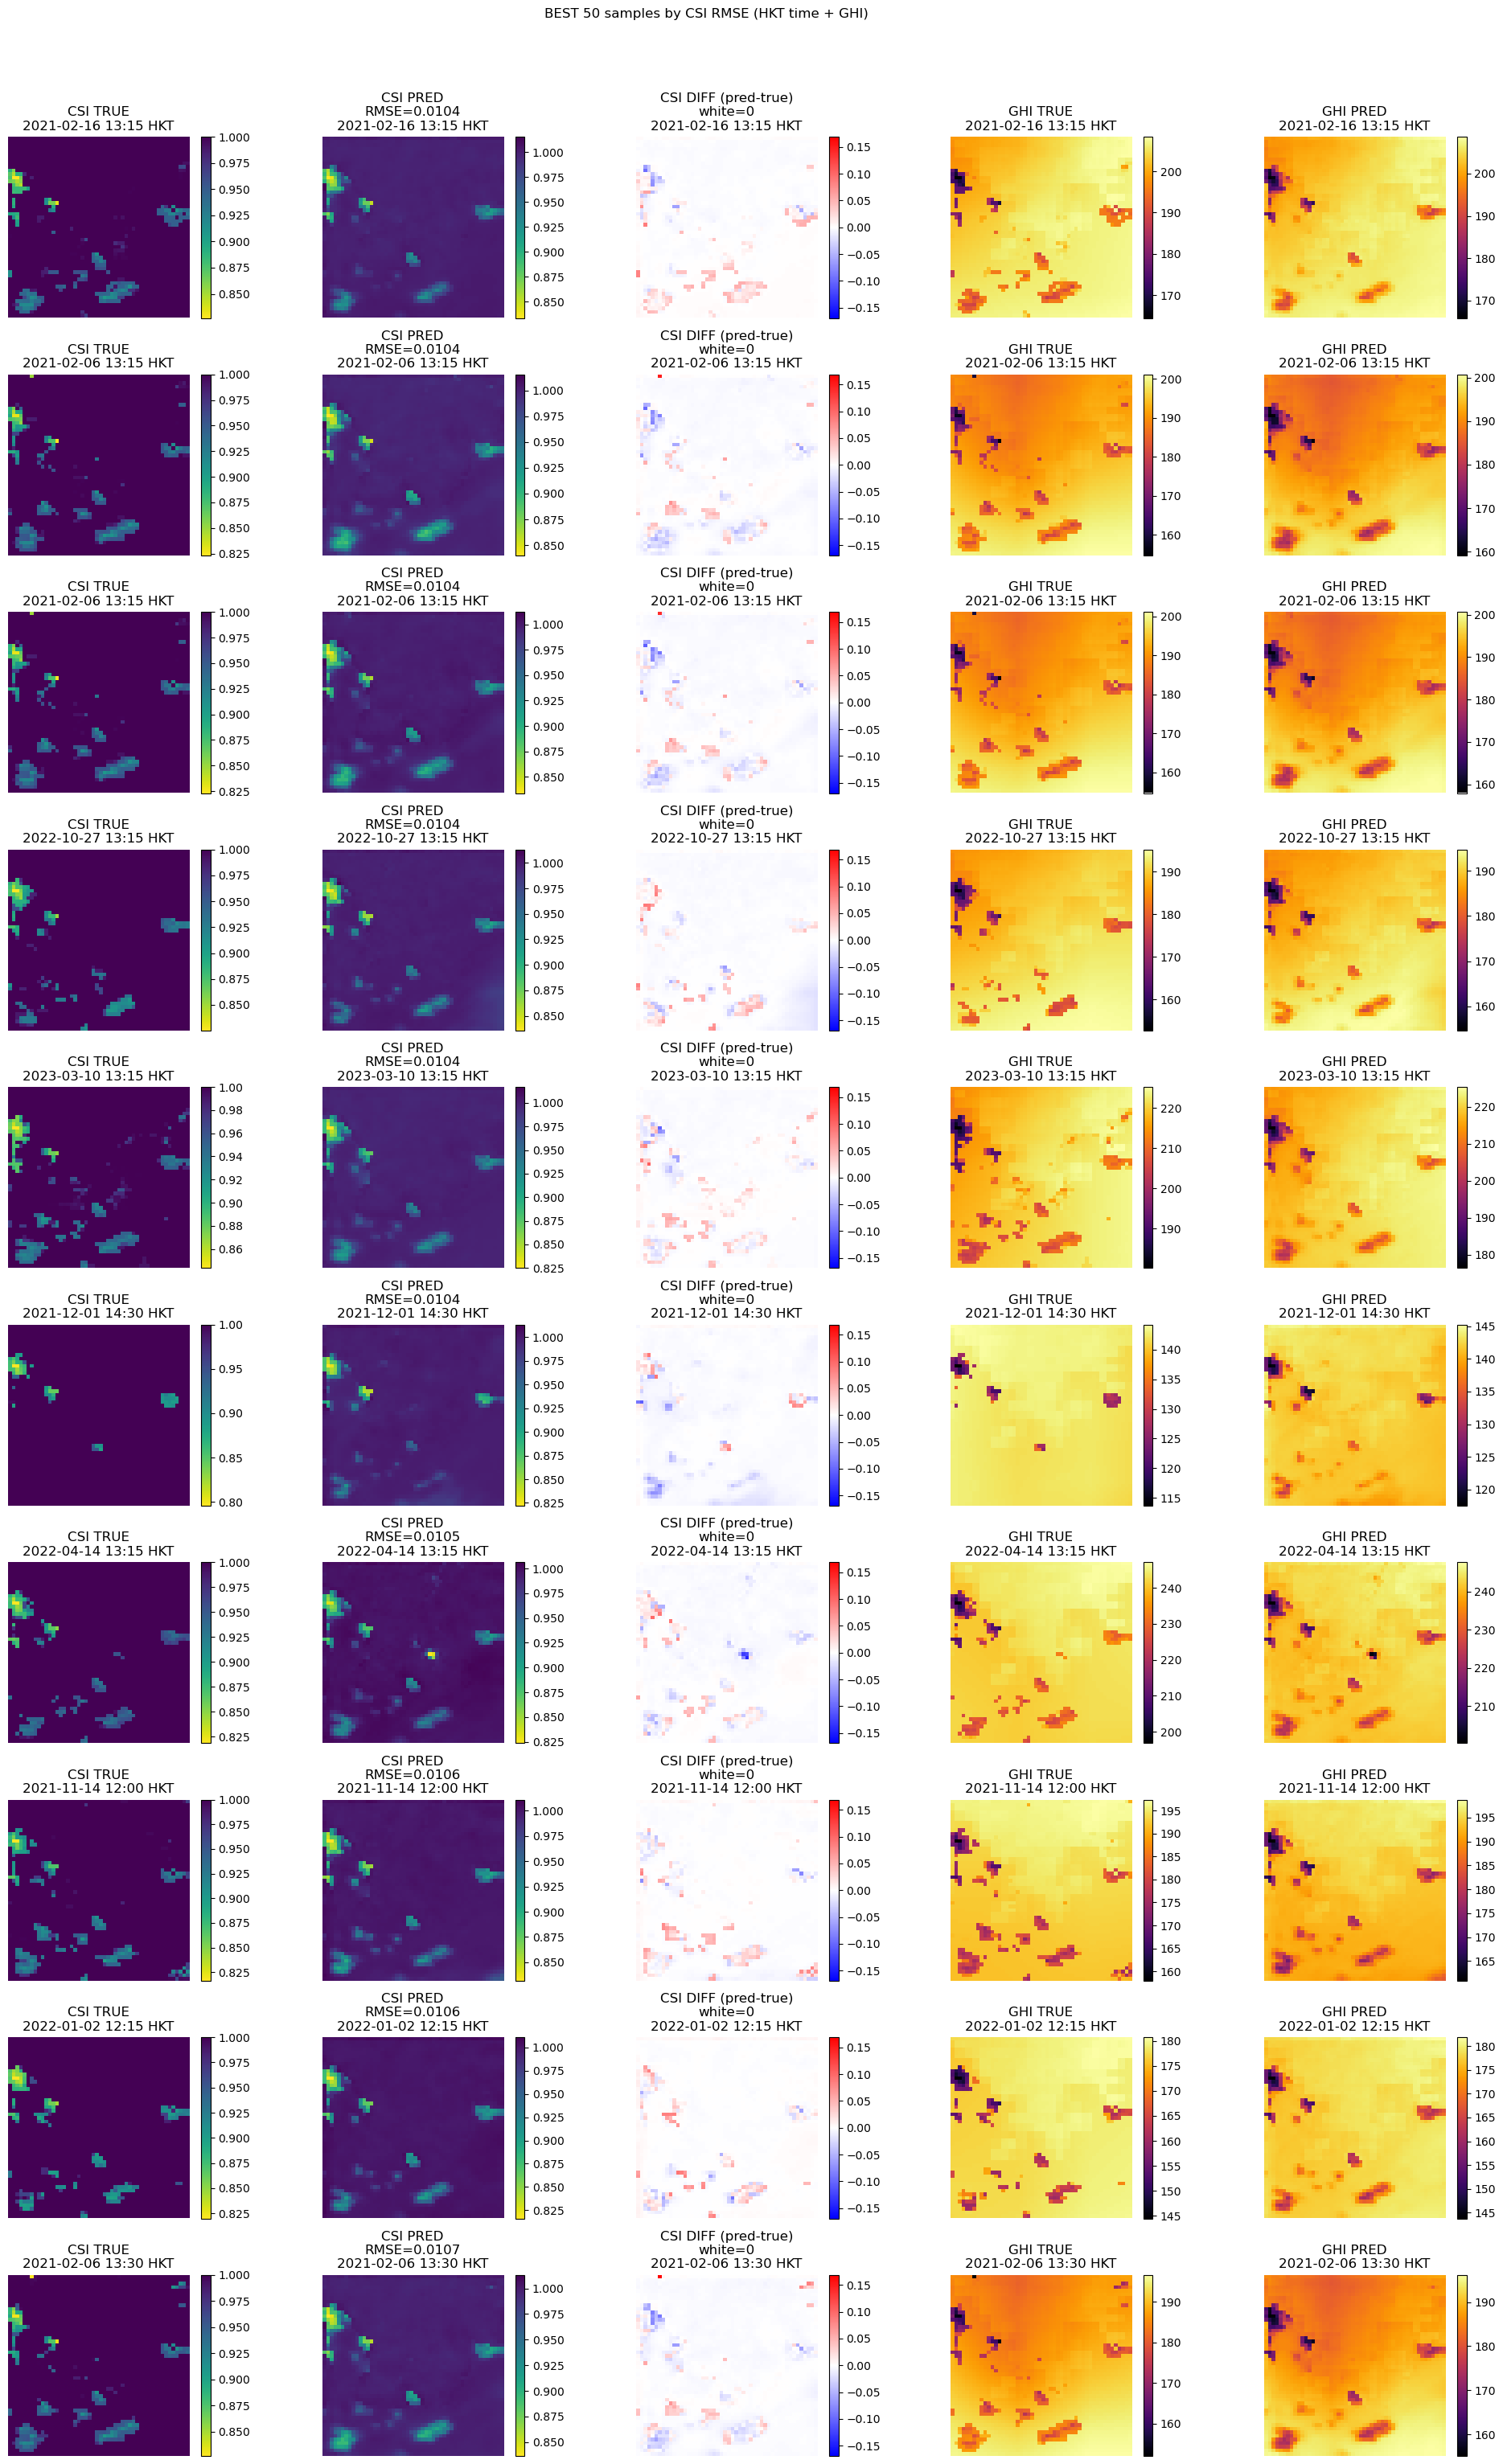

In [62]:
from src.plot import plot_rmse_extremes_with_time_and_ghi
sel, rmse_i = plot_rmse_extremes_with_time_and_ghi(
    model, test_loader, device,
    ghi_cs_test=ghi_cs_test,
    time_mins=time_mins,
    idx_test=idx_test,
    k=50, mode="best",
    per_fig=10,
    bins=60,
    show_pixel_error_hist=True,
    show_utc=False,   # True 的話 title 同時顯示 UTC + HKT
)


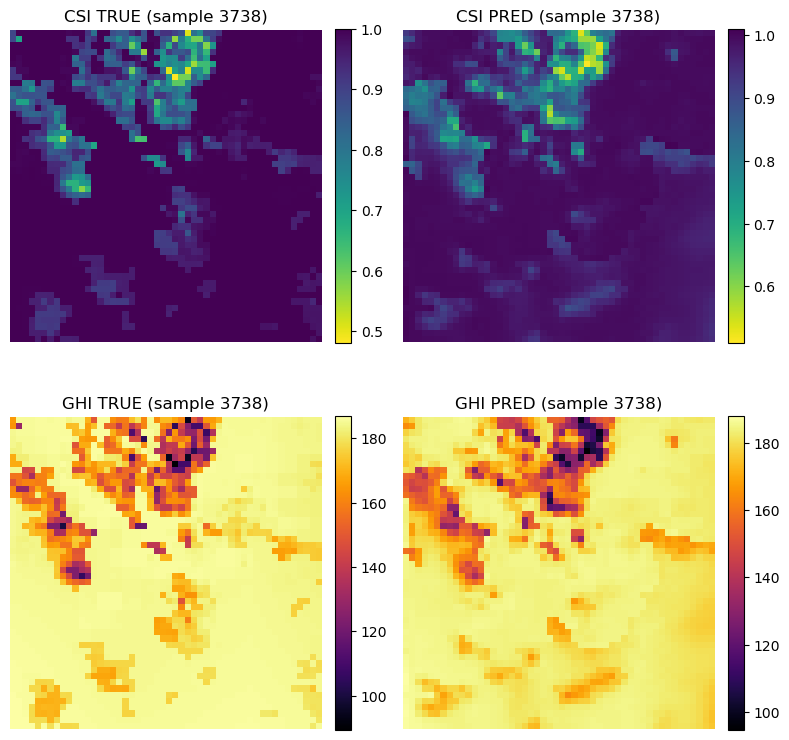

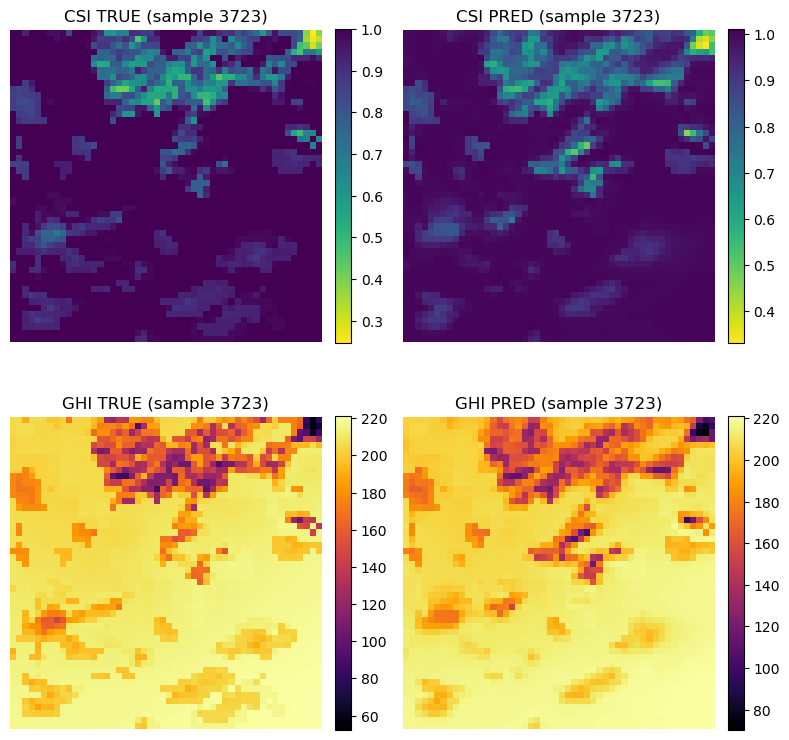

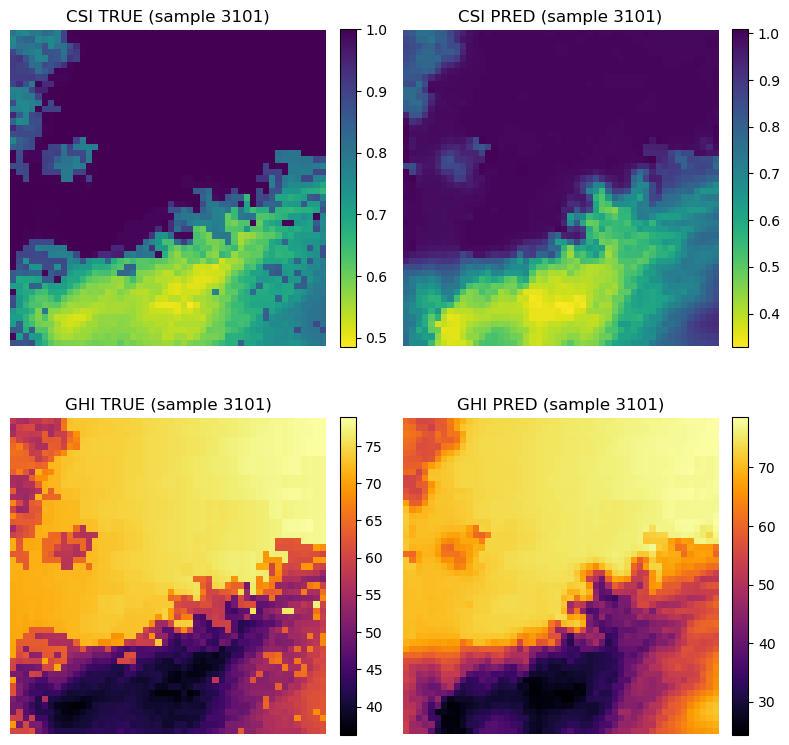

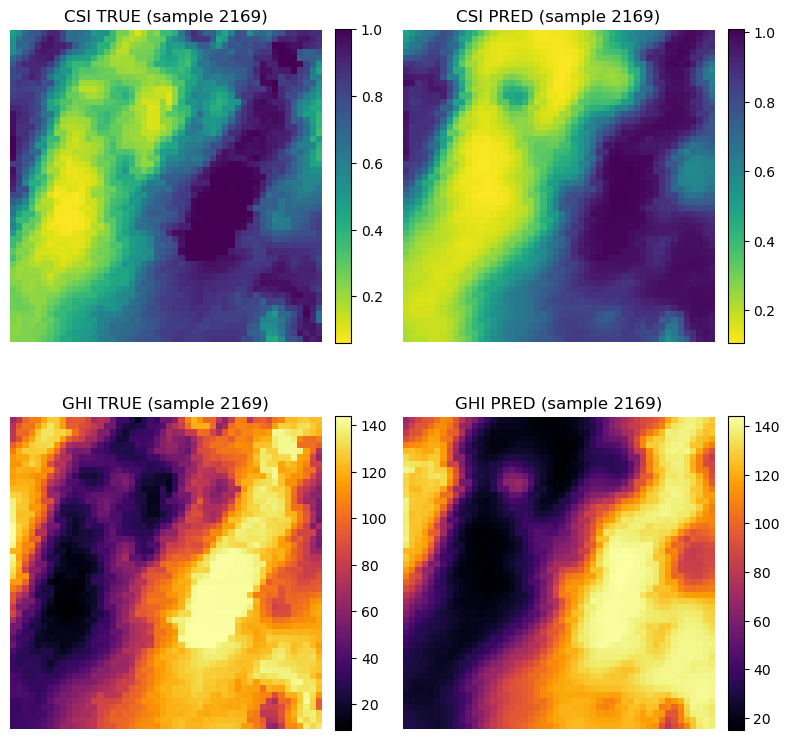

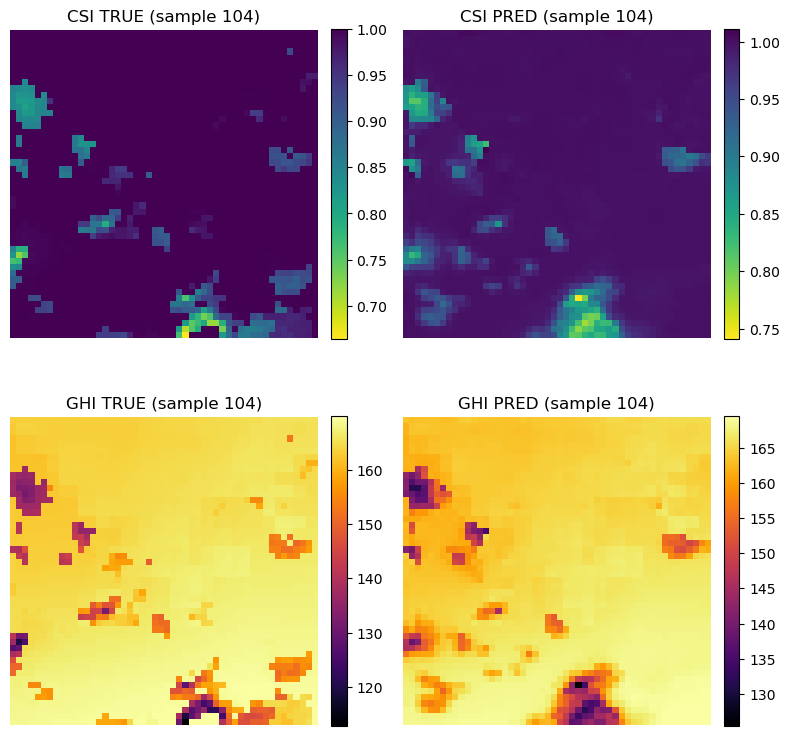

In [32]:
# model_nofuzzy = TwinFiLMUNetTiny(feature_size=48).to(device)
# model_nofuzzy.load_state_dict(torch.load("Model_checkpoint/Swin+_elevation_no_twil_30mins.pth"))

plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=5,
    seed=5
)